In [33]:
import numpy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from bisect import bisect_left, bisect_right
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GroupShuffleSplit
from sklearn.model_selection import learning_curve, GroupKFold
from sklearn.neural_network import MLPClassifier
from sklearn import metrics
from sklearn.metrics import adjusted_rand_score
from sklearn.cluster import KMeans, kmeans_plusplus, Birch, BisectingKMeans
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.utils import resample
from collections import Counter
from sklearn.decomposition import PCA
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    message="DataFrameGroupBy.apply operated on the grouping columns.*"
)

# Data Preprocessing and Feature Enigneering

In [34]:
def load_data(interference_file_name: str) -> pd.DataFrame:
    interference_df = pd.read_csv(interference_file_name, low_memory=False)

    # Encode info, channel columns to dummies
    columns_to_encode = ['info', 'channel']

    for col in columns_to_encode:
        interference_df = pd.get_dummies(interference_df, columns=[col], prefix='is')

    # Keep all relevant columns having an is_* prefix, drop the rest
    channels_to_keep = ['is_37', 'is_38', 'is_39', 'is_ADV_IND', 'is_ADV_NONCONN_IND', 'is_SCAN_REQ', 'is_ADV_EXT_IND', 'is_ADV_SCAN_IND', 'is_AUX_ADV_IND', 'is_adv_channel' ,'is_broadcast']
    other_channel_cols = [col for col in interference_df.columns if col.startswith('is_') and col not in channels_to_keep]
    interference_df = interference_df.drop(columns=other_channel_cols)
    # CHANGED: add missing dummy channels
    missing_channels = [ch for ch in channels_to_keep if ch not in interference_df.columns]
    for ch in missing_channels:
        interference_df[ch] = False



    return interference_df

In [35]:
# Calculate some source-based feature columns
def calculate_features(actual_df: pd.DataFrame, aggregated_df: pd.DataFrame) -> pd.DataFrame:
    actual_df = actual_df.sort_values(by=['source', 'time'])
    actual_df['time_to_next'] = actual_df.groupby('source')['time'].shift(-1) - actual_df['time']
    actual_df['time_to_next'] = actual_df['time_to_next'].fillna(0)
    actual_df = actual_df.sort_values(by=['source', 'time'])
    actual_df['time_diff'] = actual_df.groupby('source')['time'].diff()

    group_means = aggregated_df['mean_time_between_packets']
    actual_df['mean_time_between_packets'] = actual_df['source'].map(group_means)
    actual_df['mean_time_between_packets'] = actual_df['mean_time_between_packets'].fillna(0)

    sd_group_means = aggregated_df['service_data_mean_length']
    actual_df['service_data_mean_length'] = actual_df['source'].map(sd_group_means)
    actual_df['service_data_mean_length'] = actual_df['service_data_mean_length'].fillna(0)

    actual_df['packet_send_freq'] = actual_df['time_to_next'] / actual_df['mean_time_between_packets']
    actual_df['packet_send_freq'] = actual_df['packet_send_freq'].fillna(0)

    actual_df['service_data_len_ratio'] = actual_df['service_data'].str.len() / actual_df['service_data_mean_length']
    actual_df['service_data_len_ratio'] = actual_df['service_data_len_ratio'].fillna(0)

    ad_type_group_means = aggregated_df['ad_type_mean_length']
    actual_df['ad_type_mean_length'] = actual_df['source'].map(ad_type_group_means)
    actual_df['ad_type_mean_length'] = actual_df['ad_type_mean_length'].fillna(0)
    actual_df['ad_type_len_ratio'] = actual_df['ad_type'].str.len() / actual_df['ad_type_mean_length']
    actual_df['ad_type_len_ratio'] = actual_df['ad_type_len_ratio'].fillna(0)

    data_group_means = aggregated_df['data_mean_length']
    actual_df['data_mean_length'] = actual_df['source'].map(data_group_means)
    actual_df['data_mean_length'] = actual_df['data_mean_length'].fillna(0)
    actual_df['data_len_ratio'] = actual_df['data'].str.len() / actual_df['data_mean_length']
    actual_df['data_len_ratio'] = actual_df['data_len_ratio'].fillna(0)

    uuid16_group_means = aggregated_df['uuid16_mean_length']
    actual_df['uuid16_mean_length'] = actual_df['source'].map(uuid16_group_means)
    actual_df['uuid16_mean_length'] = actual_df['uuid16_mean_length'].fillna(0)
    actual_df['uuid16_len_ratio'] = actual_df['uuid16'].str.len() / actual_df['uuid16_mean_length']
    actual_df['uuid16_len_ratio'] = actual_df['uuid16_len_ratio'].fillna(0)

    # Drop intermediate columns as they were only used to help the calculation
    actual_df = actual_df.drop(columns=['mean_time_between_packets', 'time_diff', 'service_data_mean_length', 'ad_type_mean_length', 'data_mean_length', 'uuid16_mean_length'])
    
    return actual_df

In [36]:
# Group dataframe by source and extract some metrics
def aggregate_features(group_filter: str, input_df: pd.DataFrame) -> pd.DataFrame:
    input_df = input_df.sort_values(by=['source', 'time'])
    input_df['time_diff'] = input_df.groupby('source')['time'].diff()

    agg_df = input_df.groupby(group_filter).agg(
        ad_type_mean_length=('ad_type', lambda x: x.str.len().mean()),
        data_mean_length=('data', lambda x: x.str.len().mean()),
        uuid16_mean_length=('uuid16', lambda x: x.str.len().mean()),
        service_data_mean_length=('service_data', lambda x: x.str.len().mean()),
        mean_time_between_packets=('time_diff', 'mean'),
    )
    
    return agg_df

In [37]:
def combine_data(interference_df: pd.DataFrame, target_labels: list) -> pd.DataFrame:
    # Aggregate dataframe by source and calculate new columns
    interfered_df_agg = aggregate_features('source', interference_df)
    interfered_df_calc = calculate_features(interference_df, interfered_df_agg)

    # For multi-group file we already have ground truth: group_id 0/1/2, group_label_bin, group_label_multi
    # Preserve them if present, otherwise fall back to labelled_device heuristic (single-group legacy)
    if 'group_label_bin' in interfered_df_calc.columns and 'group_label_multi' in interfered_df_calc.columns:
        interfered_df_calc['group_label'] = interfered_df_calc['group_label_bin']  # binary 0 vs (G1+G2)
        # keep group_label_multi and group_id as is for 3-class tasks
    elif 'group_id' in interfered_df_calc.columns:
        interfered_df_calc['group_label'] = (interfered_df_calc['group_id'] != 0).astype(int)
        interfered_df_calc['group_label_multi'] = interfered_df_calc['group_id']
    else:
        interfered_df_calc['group_label'] = interfered_df_calc['labelled_device'].apply(
            lambda x: 1 if x in target_labels else 0
        )
        interfered_df_calc['group_label_multi'] = interfered_df_calc['group_label']

    return interfered_df_calc


In [38]:
##############################
#        CODE FIELD 1        # 
##############################

# --- Adapted for SINGLE labeled file: 2Groups_3Devices_FirstExperiment_labeled.csv ---
# Original samsung notebook used 3 apart files for training + uni for evaluation.
# With only one 20min capture we do within-capture evaluation via GroupShuffleSplit and time-split.

# List of target labels for device type (binary baseline). Use group_id for multi-group.
target_list = ['Phone', 'Buds', 'AirTag']  # was ['Phone','Buds','Smart Tag'] - AirTag is Apple hybrid

# Load single multi-group labeled dataset (created by dataset_labeling_MultiGroupFirstExperiment.ipynb)
single_df = load_data('../../data/2Groups_3Devices_FirstExperiment/2Groups_3Devices_FirstExperiment_labeled.csv')
print(f"Loaded single dataset: {len(single_df)} packets, {single_df['source'].nunique()} sources")
print(single_df.groupby('labelled_device').agg(packets=('labelled_device','size'), sources=('source','nunique')))
if 'group_id' in single_df.columns:
    print(single_df.groupby('group_id').agg(packets=('group_id','size'), sources=('source','nunique')))
    print(single_df.groupby(['labelled_device','group_id']).agg(packets=('labelled_device','size')))

# Calculate aggregated features for the single dataset
int_single = combine_data(single_df, target_list)
print(f"Length Single Dataset after feature calc: {len(int_single)}")
print(f"Binary group_label distribution: {int_single['group_label'].value_counts().to_dict()}")
if 'group_label_multi' in int_single.columns:
    print(f"Multi-class group_label_multi distribution: {int_single['group_label_multi'].value_counts().to_dict()}")

# Keep legacy variable names for compatibility with downstream cells
# For single-file workflow we alias int_single to all four variables, training will split via GroupShuffleSplit.
int_apart_1 = int_single
int_apart_2 = int_single
int_apart_3 = int_single
int_df_4 = int_single


Loaded single dataset: 66618 packets, 721 sources
                 packets  sources
labelled_device                  
AirTag              3130        2
Buds               22950        2
Phone               5289       16
empty              35249      701
          packets  sources
group_id                  
0           36575      710
1           15891        5
2           14152        6
                          packets
labelled_device group_id         
AirTag          1            1602
                2            1528
Buds            1           11702
                2           11248
Phone           0            1326
                1            2587
                2            1376
empty           0           35249
Length Single Dataset after feature calc: 66618
Binary group_label distribution: {0: 36575, 1: 30043}
Multi-class group_label_multi distribution: {0: 36575, 1: 15891, 2: 14152}


In [39]:
##############################
#        CODE FIELD 2        #
##############################

# Create time-based features by counting packets within time windows per source
# For single-file workflow we process only int_single and replicate via alias
dataframes = [int_single]

for i in range(len(dataframes)):
    df = dataframes[i].sort_values(by=['source', 'time']).reset_index(drop=True)

    df['packets_within_1s'] = 0
    df['packets_within_100ms'] = 0
    df['packets_within_25ms'] = 0
    df['packets_within_2ms'] = 0
    df['time'] = df['time'].astype(float)

    def count_within_window(group, window, col_name):
        times = group['time'].values
        counts = []
        for t in times:
            left = bisect_left(times, t - window)
            right = bisect_right(times, t + window)
            counts.append(right - left - 1)
        group[col_name] = counts
        return group

    df = df.groupby('source', group_keys=False).apply(count_within_window, window=1.0, col_name='packets_within_1s')
    df = df.groupby('source', group_keys=False).apply(count_within_window, window=0.1, col_name='packets_within_100ms')
    df = df.groupby('source', group_keys=False).apply(count_within_window, window=0.025, col_name='packets_within_25ms')
    df = df.groupby('source', group_keys=False).apply(count_within_window, window=0.002, col_name='packets_within_2ms')

    # Re-assign updated DataFrame
    dataframes[i] = df

int_single = dataframes[0]
# Re-alias for compatibility
int_apart_1, int_apart_2, int_apart_3, int_df_4 = int_single, int_single, int_single, int_single


In [40]:
##############################
#      CODE FIELD 2b - Group Interconnect Features #
##############################
# Extends per-packet df with temporal co-activity, payload sync and instance timing fingerprint
# These capture coordinated burst behaviour of devices carried together (same group)

def add_group_interconnect_features(df, win=0.5):
    df = df.sort_values('time').copy()
    df['time'] = df['time'].astype(float)
    # 1) Temporal co-activity: bins of win seconds
    df['time_bin_500ms'] = (df['time'] // win).astype(int)
    # per-bin total packets and distinct sources (without leaking group_id)
    bin_size = df.groupby('time_bin_500ms').size().rename('bin_total_packets')
    bin_sources = df.groupby('time_bin_500ms')['source'].nunique().rename('bin_distinct_sources')
    bin_source_set = df.groupby('time_bin_500ms')['source'].apply(lambda x: set(x))

    df = df.join(bin_size, on='time_bin_500ms')
    df = df.join(bin_sources, on='time_bin_500ms')

    # per-packet: other packets/sources co-active in same window (excluding self-packet)
    df['coactive_packets_in_bin'] = df['bin_total_packets'] - 1
    df['coactive_sources_in_bin'] = df['bin_distinct_sources'] - 1
    df['coactive_density'] = df['coactive_packets_in_bin'] / (df['bin_total_packets'].clip(lower=1))
    df['is_solo_bin'] = (df['coactive_sources_in_bin'] == 0).astype(int)

    # For G1 vs G2 separation: Jaccard-style co-occurrence with known whitelist is NOT used as feature
    # to avoid label leakage. Instead we use raw co-activity; grouping will be discovered unsupervised.

    # 2) Coordinated payload / status-bit change
    # Buds use Data 420981... , AirTag 1219... prefix covers status bits
    df['data_prefix10'] = df['data'].astype(str).str[:10]
    df['service_data_prefix8'] = df['service_data'].astype(str).str[:8]
    # per-source payload change flag
    df['payload_changed'] = (df.groupby('source')['data_prefix10'].shift(1) != df['data_prefix10']).astype(int)
    df['payload_changed'] = df['payload_changed'].fillna(0)
    # per-bin sync: how many sources flipped payload in same bin (coordinated change)
    bin_flips = df.groupby('time_bin_500ms')['payload_changed'].sum().rename('bin_sync_flips')
    df = df.join(bin_flips, on='time_bin_500ms')
    df['payload_sync_in_bin'] = df['bin_sync_flips']  # 0..n, high when group moves together
    # normalized sync density
    df['payload_sync_density'] = df['bin_sync_flips'] / df['bin_distinct_sources'].clip(lower=1)

    # 3) Instance-level timing fingerprint (per-source IAT jitter + burst)
    # Already have time_to_next/packet_send_freq, here add robust IAT stats mapped per source
    df['time_diff'] = df.groupby('source')['time'].diff()
    iat_median = df.groupby('source')['time_diff'].median().rename('iat_median')
    iat_std = df.groupby('source')['time_diff'].std().rename('iat_std')
    iat_mean = df.groupby('source')['time_diff'].mean().rename('iat_mean')
    df = df.join(iat_median, on='source')
    df = df.join(iat_std, on='source')
    df = df.join(iat_mean, on='source')
    # fill
    df['iat_std'] = df['iat_std'].fillna(0)
    df['iat_median'] = df['iat_median'].fillna(0)
    df['iat_mean'] = df['iat_mean'].fillna(0)
    # per-packet IAT deviation from source median (instance fingerprint)
    df['iat_deviation'] = (df['time_diff'] - df['iat_median']).abs().fillna(0)
    # burst indicator: very short IAT (<5ms) repeated -> hardware timer fingerprint
    df['is_burst_iat'] = (df['time_diff'] < 0.005).astype(int)

    # Clean up temporary diff
    df = df.drop(columns=['time_diff'])
    return df

# Apply to single dataset (and keep alias)
int_single = add_group_interconnect_features(int_single, win=0.5)
print(f"Added interconnect features: coactive_packets_in_bin, coactive_sources_in_bin, payload_sync_in_bin, iat_*")
print(int_single[['coactive_packets_in_bin','coactive_sources_in_bin','payload_sync_in_bin','iat_median','iat_std']].describe().to_string())
# Re-alias
int_apart_1, int_apart_2, int_apart_3, int_df_4 = int_single, int_single, int_single, int_single


Added interconnect features: coactive_packets_in_bin, coactive_sources_in_bin, payload_sync_in_bin, iat_*
       coactive_packets_in_bin  coactive_sources_in_bin  payload_sync_in_bin    iat_median       iat_std
count             66618.000000             66618.000000         66618.000000  66618.000000  66618.000000
mean                 27.063256                 6.561590             5.445765      0.661379      0.692469
std                   8.466185                 1.794858             3.200250     12.094885      7.722813
min                   9.000000                 3.000000             0.000000      0.000000      0.000000
25%                  22.000000                 5.000000             3.000000      0.000874      0.100926
50%                  26.000000                 6.000000             5.000000      0.007335      0.105032
75%                  31.000000                 8.000000             7.000000      0.180504      0.119663
max                 148.000000                14.00000

In [41]:
# Will ensure that only n(=max_entries) values per source address may be part of a dataset
def create_balanced_df(input_df: pd.DataFrame, max_entries: int=1000) -> pd.DataFrame:
    output_df = (
    input_df.groupby(['source'])
    .apply(lambda x: x.sample(min(len(x), max_entries), random_state=1))
    .reset_index(drop=True)
    )

    print(len(output_df))
    return output_df

# Bin the column by assigning into quantiles, equal/duplicate quantiles are dropped
def bin_column(df_to_edit: pd.DataFrame, column_to_bin: str, binned_column_name: str, quantile_amount: int = 15) -> pd.DataFrame:
    qcut_result = pd.qcut(df_to_edit[column_to_bin], q=quantile_amount, duplicates='drop')
    df_to_edit[binned_column_name] = qcut_result.cat.codes
    return df_to_edit

In [42]:
##############################
#        CODE FIELD 3        #
##############################

# Renaming config of binned columns
binning_config = {
    'len_ad_type':  'len_ad_type_binned',
    'len_data':  'len_data_binned',
    'len_uuid16':  'len_uuid16_binned',
    'len_service_data':  'len_service_data_binned',
    'time_start_end':  'time_start_end_binned',
    'delta_end_start':  'delta_end_start_binned',
    'delta_start_start':  'delta_start_start_binned',
    'packet_send_freq':  'packet_send_freq_binned',
    'time_to_next':  'time_to_next_binned',
    'uuid16_len_ratio': 'uuid16_len_ratio_binned',
    'data_len_ratio': 'data_len_ratio_binned',
    'ad_type_len_ratio': 'ad_type_len_ratio_binned',
}

# For single-file workflow: use int_single as base for both train and eval
# Downstream supervised code will do train/test split via GroupShuffleSplit, so we keep full data here
train_df_large = int_single.copy()
train_df_medium = int_single.copy()
train_df_binned_large = train_df_large.copy()
train_df_binned_medium = train_df_medium.copy()
eval_df = int_single.copy()
eval_df_binned = eval_df.copy()


# Create binned dataframes with 15 quantiles
max_bins = 15
for column, new_column in binning_config.items():
    train_df_binned_large = bin_column(train_df_binned_large, column, new_column, max_bins)
    train_df_binned_medium = bin_column(train_df_binned_medium, column, new_column, max_bins)
    eval_df_binned = bin_column(eval_df_binned, column, new_column, max_bins)

# Create balanced dataframes limiting to max 1000 entries per source
train_df_large_balanced = create_balanced_df(train_df_large.copy(), max_entries=1000)
train_df_medium_balanced = create_balanced_df(train_df_medium.copy(), max_entries=1000)
train_df_binned_large_balanced = create_balanced_df(train_df_binned_large.copy(), max_entries=1000)
train_df_binned_medium_balanced = create_balanced_df(train_df_binned_medium.copy(), max_entries=1000)
eval_balanced = create_balanced_df(eval_df.copy(), max_entries=1000)
eval_df_binned_balanced = create_balanced_df(eval_df_binned.copy(), max_entries=1000)

print(f"train_df_binned_large_balanced: {len(train_df_binned_large_balanced)}, eval_df_binned_balanced: {len(eval_df_binned_balanced)} (same underlying capture - eval is within-capture holdout via GroupShuffleSplit)")


19186
19186
19186
19186
19186
19186
train_df_binned_large_balanced: 19186, eval_df_binned_balanced: 19186 (same underlying capture - eval is within-capture holdout via GroupShuffleSplit)


In [43]:
df_train_group_0 = train_df_binned_large_balanced[train_df_binned_large_balanced["labelled_device"] == "empty"]
df_train_group_1 = train_df_binned_large_balanced[train_df_binned_large_balanced["labelled_device"] != "empty"]
print(f"Training set 1: Noise {round(100*(len(df_train_group_0)/len(train_df_binned_large_balanced)), 2)}, Target Group {round(100*(len(df_train_group_1)/len(train_df_binned_large_balanced)), 2)}")

df_eval_group_0 = eval_df_binned_balanced[eval_df_binned_balanced["labelled_device"] == "empty"]
df_eval_group_1 = eval_df_binned_balanced[eval_df_binned_balanced["labelled_device"] != "empty"]
print(f"Evaluation set 1: Noise {round(100*(len(df_eval_group_0)/len(eval_df_binned_balanced)), 2)}, Target Group {round(100*(len(df_eval_group_1)/len(eval_df_binned_balanced)), 2)}")

Training set 1: Noise 51.58, Target Group 48.42
Evaluation set 1: Noise 51.58, Target Group 48.42


# Supervised Learning

In [44]:
def split_data(base_df: pd.DataFrame, X: pd.DataFrame, y: pd.Series, test_size: float, split_mode_group: bool=False):
  # Split with the train_test_split method
  if not split_mode_group:
    X_train, X_test, y_train, y_test = train_test_split(
      X, y, stratify=y, test_size=test_size, random_state=1, shuffle=True)

  # Split by grouping by source addresses with GroupShuffleSplit
  elif split_mode_group:
    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=1)

    train_idx, test_idx = next(gss.split(X, y, groups=base_df.source))
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

  return X_train, X_test, y_train, y_test

In [45]:
def fit_and_predict_model(X_train: pd.DataFrame, X_test: pd.DataFrame, y_train: pd.Series, y_test: pd.DataFrame, model):
  model = model.fit(X_train, y_train)

  # 5-fold cross-validation
  train_acc = accuracy_score(y_train, model.predict(X_train))
  test_acc = accuracy_score(y_test, model.predict(X_test))
  cv_scores = cross_val_score(model, X_train, y_train, cv=5)

  print(f'Train Accuracy: {train_acc:.4f}')
  print(f'Test Accuracy:  {test_acc:.4f}')
  print(f'CV Accuracy (mean ± std): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

  y_pred = model.predict(X_test)
  return model, y_pred

In [46]:
def create_matrix(model,
                  y_test: pd.Series,
                  y_pred: numpy.ndarray,
                  model_name: str,
                  split_mode: bool=False,
                  model_type: str='Training'
                  ):
  cm = confusion_matrix(y_test, y_pred, normalize='true')
  grouping = 'Grouped' if split_mode else 'Regular'

  # Show matrix
  disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
  disp.plot(cmap=plt.cm.Blues, values_format='.2%')
  plt.title(f'{model_name} - {model_type} - {grouping}')
  plt.tight_layout()
  plt.show()

In [47]:
def evaluate_model(model,
                   model_name: str,
                   eval_df: pd.DataFrame,
                   split_mode: bool=False,
                   balance_mode: bool=False,
                   label_col: str='group_label'
                   ):
  # label_col = 'group_label' for binary, 'group_label_multi' for 3-class
  X_new = eval_df.drop(columns=[c for c in dropped_columns + ['group_label','group_label_multi','group_label_bin','group_id'] if c in eval_df.columns])
  # Ensure same columns as training: intersect with dropped_columns logic
  # Use training columns: X_new = eval_df.drop(columns=dropped_columns + [label_col]) would be more precise
  # Fallback: drop known label cols
  y_new_pred = model.predict(X_new)
  y_true = eval_df[label_col]

  print(f'Evaluation on Test Dataset (label={label_col}):')
  print(classification_report(y_true, y_new_pred, zero_division=0))

  create_matrix(
            model = model,
            y_test = y_true,
            y_pred = y_new_pred,
            model_name = model_name,
            split_mode=split_mode,
            model_type='Evaluation'
        )


In [48]:
def model_feature_importance(model, X_test: pd.DataFrame,
                             y_test: pd.Series,
                             model_name: str,
                             model_type: str):
    all_feature_names = X_test.columns

    # Only Random Forest has native feature importance
    if 'Random Forest' in model_name:
        model_features = model.feature_importances_
        importance_df = pd.DataFrame({
                'Feature': all_feature_names,
                'Importance': model_features
            }).sort_values(by='Importance', ascending=False)

        plt.figure(figsize=(10, 6))
        plt.barh(importance_df['Feature'][:10][::-1], importance_df['Importance'][:10][::-1])
        plt.xlabel('Feature Importance')
        plt.title(f'Top 10 Features: Random Forest - {model_type}')
        plt.tight_layout()
        plt.show()
    else:
        perm_result = permutation_importance(model, X_test, y_test, n_repeats=5, random_state=1)
        importance_df = pd.DataFrame({
            'Feature': all_feature_names,
            'Importance': perm_result.importances_mean
            }).sort_values(by='Importance', ascending=False)

        print('\nPermutation Importance:')
        print(importance_df.head(10))

        plt.figure(figsize=(10, 6))
        plt.barh(importance_df['Feature'][:10][::-1], importance_df['Importance'][:10][::-1])
        plt.xlabel('Permutation Importance')
        plt.title(f'Top 10 Features: {model_name} - {model_type}')
        plt.tight_layout()
        plt.show()

In [49]:
##############################
#        CODE FIELD 4        #
##############################

# Downsample for class balance check
# For binary: 0 vs 1 ; For multi-class: 0 vs 1 vs 2
# Here we keep binary downsample as example, multi-class uses group_label_multi

df_0 = eval_df_binned_balanced[eval_df_binned_balanced['group_label'] == 0].copy()
df_1 = eval_df_binned_balanced[eval_df_binned_balanced['group_label'] == 1].copy()

# Randomly undersample class 0 (=noise) to 2* len(df_1) for binary evaluation
df_0_downsampled = resample(df_0,
                            replace=False,
                            n_samples=min(len(df_0), 2*len(df_1)),
                            random_state=1)

# Create downsampled evaluation dataset (binary)
eval_df_balanced_down = pd.concat([df_0_downsampled, df_1])

# For 3-class keep separate counts
if 'group_label_multi' in eval_df_binned_balanced.columns:
    df_g0 = eval_df_binned_balanced[eval_df_binned_balanced['group_label_multi']==0]
    df_g1 = eval_df_binned_balanced[eval_df_binned_balanced['group_label_multi']==1]
    df_g2 = eval_df_binned_balanced[eval_df_binned_balanced['group_label_multi']==2]
    print(f"Multi-class counts: noise {len(df_g0)}, G1 {len(df_g1)}, G2 {len(df_g2)}")


Multi-class counts: noise 11223, G1 4587, G2 3376


In [50]:
# These columns are dropped before training and not used for supervised learning
dropped_columns = [
    'time',
    'source',
    'destination',
    'length',
    'rssi',
    'company_id',
    'device_name',
    'uuid16',
    'uuid128',
    'data',
    'ad_type',
    'service_data',
    'crc',
    'labelled_device',
    'sublabel_device',
    'packet_send_freq',
    'time_to_next',
    'time_start_end',
    'delta_end_start',
    'delta_start_start',
    'len_ad_type',
    'len_data',
    'len_uuid16',
    'len_service_data',
    'has_uuid128',
    'uuid16_len_ratio',
    'data_len_ratio',
    'ad_type_len_ratio',
    'len_uuid16_binned',
    'len_service_data_binned',
    'uuid16_len_ratio_binned',
    'group_id',
    'group_label',
    'group_label_bin',
    'group_label_multi',

    'data_prefix10',
    'service_data_prefix8',
    'time_bin_500ms',  # bin index not needed as feature (derived)

    # NOTE: keep co-activity features: coactive_*, payload_sync_*, iat_* (not dropped)
    # group cols are dropped via label handling in CODE FIELD 6, not here

]

# Defines the train/test split ratio
test_param = 0.3

# If only one model should be run at a time, simply comment out the other two models
model_dict = {
    'Random Forest': RandomForestClassifier(random_state=1,
                                            class_weight='balanced',
                                            n_estimators=50,
                                            min_samples_split=10,
                                            min_samples_leaf=3,
                                            min_weight_fraction_leaf=0.002
    ),

    'Multi-layer Perceptron': Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('clf',MLPClassifier(max_iter = 200,
                             verbose = True,
                             random_state = 1,
                             tol = 0.0001,
                             early_stopping = True,
                             validation_fraction = 0.25,
                             activation='tanh',
                             hidden_layer_sizes=250)),
    ]),

    'Stochastic Gradient Descent': Pipeline(steps=[
      ('scaler', StandardScaler()),
      ('clf', SGDClassifier(loss='huber',
                            max_iter=10000,
                            random_state=1,
                            class_weight='balanced',
                            alpha=0.0001))
    ]),
}

In [51]:
##############################
#        CODE FIELD 5        #
##############################

# Print cardinalites per feature column and compare training and evaluation
for column in train_df_binned_large_balanced.drop(columns=dropped_columns).columns:
    card_train = train_df_binned_large_balanced[column].nunique()
    try:
        card_eval = eval_df_binned_balanced[column].nunique()
    except KeyError:
        card_eval = 0
    calc_card = (card_train + card_eval) / 2
    print(f'AVG cardinality for {column}: {calc_card} --> based on: {card_train, card_eval}')

AVG cardinality for is_broadcast: 1.0 --> based on: (1, 1)
AVG cardinality for has_company_id: 2.0 --> based on: (2, 2)
AVG cardinality for is_adv_channel: 1.0 --> based on: (1, 1)
AVG cardinality for has_uuid16: 2.0 --> based on: (2, 2)
AVG cardinality for is_ADV_IND: 2.0 --> based on: (2, 2)
AVG cardinality for is_ADV_NONCONN_IND: 2.0 --> based on: (2, 2)
AVG cardinality for is_ADV_SCAN_IND: 2.0 --> based on: (2, 2)
AVG cardinality for is_SCAN_REQ: 2.0 --> based on: (2, 2)
AVG cardinality for is_37: 2.0 --> based on: (2, 2)
AVG cardinality for is_38: 2.0 --> based on: (2, 2)
AVG cardinality for is_39: 2.0 --> based on: (2, 2)
AVG cardinality for is_ADV_EXT_IND: 1.0 --> based on: (1, 1)
AVG cardinality for is_AUX_ADV_IND: 1.0 --> based on: (1, 1)
AVG cardinality for service_data_len_ratio: 2.0 --> based on: (2, 2)
AVG cardinality for packets_within_1s: 42.0 --> based on: (42, 42)
AVG cardinality for packets_within_100ms: 20.0 --> based on: (20, 20)
AVG cardinality for packets_within_2

USING COLUMNS: ['is_broadcast', 'has_company_id', 'is_adv_channel', 'has_uuid16', 'is_ADV_IND', 'is_ADV_NONCONN_IND', 'is_ADV_SCAN_IND', 'is_SCAN_REQ', 'is_37', 'is_38', 'is_39', 'is_ADV_EXT_IND', 'is_AUX_ADV_IND', 'service_data_len_ratio', 'packets_within_1s', 'packets_within_100ms', 'packets_within_25ms', 'packets_within_2ms', 'bin_total_packets', 'bin_distinct_sources', 'coactive_packets_in_bin', 'coactive_sources_in_bin', 'coactive_density', 'is_solo_bin', 'payload_changed', 'bin_sync_flips', 'payload_sync_in_bin', 'payload_sync_density', 'iat_median', 'iat_std', 'iat_mean', 'iat_deviation', 'is_burst_iat', 'len_ad_type_binned', 'len_data_binned', 'time_start_end_binned', 'delta_end_start_binned', 'delta_start_start_binned', 'packet_send_freq_binned', 'time_to_next_binned', 'data_len_ratio_binned', 'ad_type_len_ratio_binned']
Training with label=group_label_multi, distribution: {0: 11223, 1: 4587, 2: 3376}
Eval within-capture distribution: {0: 11223, 1: 4587, 2: 3376} (same capture

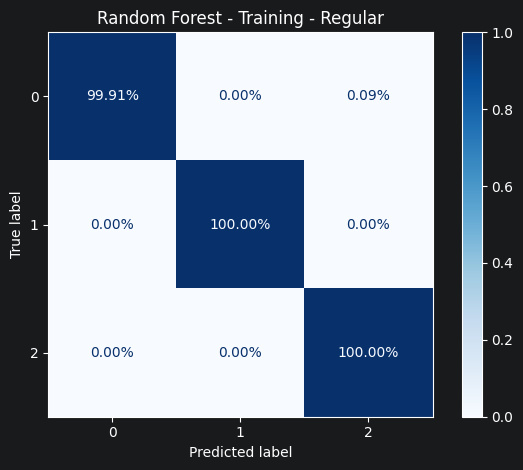

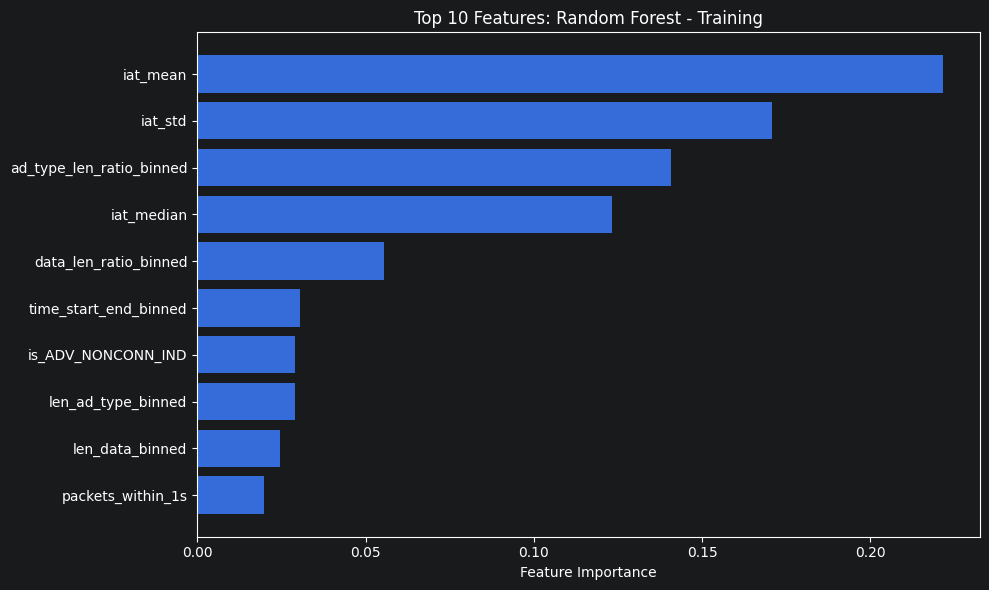

Evaluation on Test Dataset (label=group_label_multi):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11223
           1       1.00      1.00      1.00      4587
           2       1.00      1.00      1.00      3376

    accuracy                           1.00     19186
   macro avg       1.00      1.00      1.00     19186
weighted avg       1.00      1.00      1.00     19186



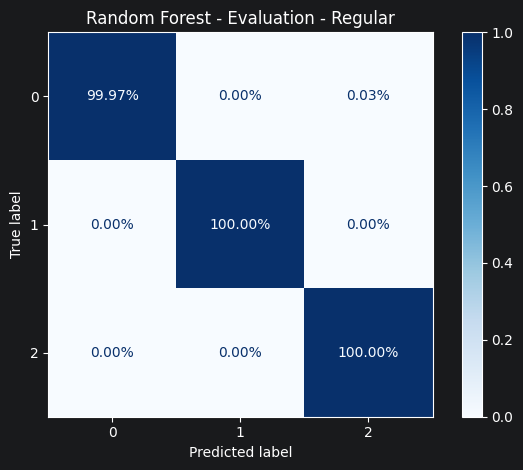

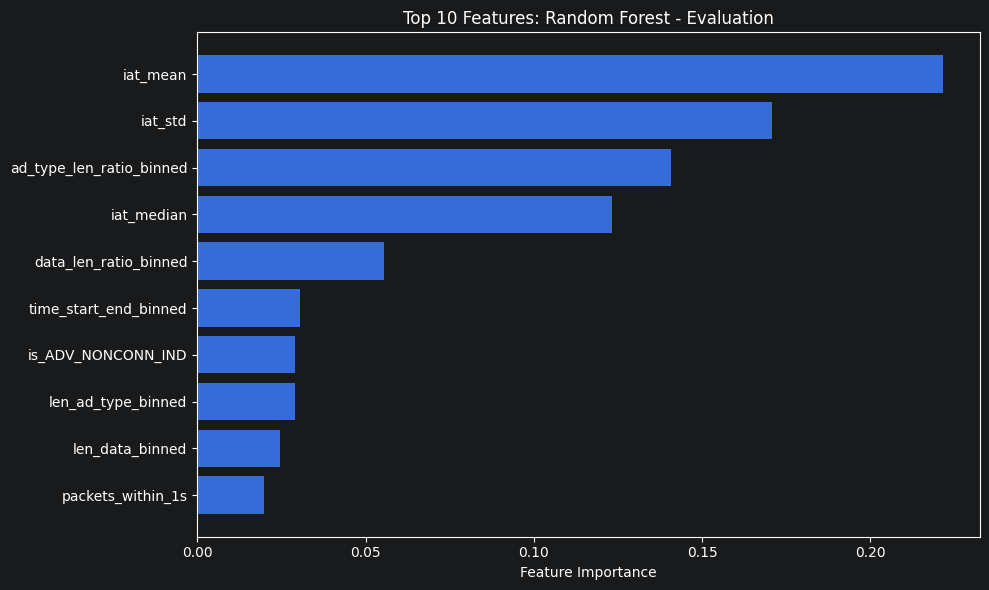


------------------------------------------------------------
STARTING MODEL: Random Forest WITH GROUPED SPLIT MODE: True AND TEST SIZE: 0.3 LABEL: group_label_multi
------------------------------------------------------------

Train Accuracy: 0.9999
Test Accuracy:  0.6650
CV Accuracy (mean ± std): 0.8469 ± 0.1959
Model Random Forest               precision    recall  f1-score   support

           0       0.72      1.00      0.84      2590
           1       1.00      0.46      0.63      1864
           2       0.34      0.34      0.34      1516

    accuracy                           0.66      5970
   macro avg       0.69      0.60      0.60      5970
weighted avg       0.71      0.66      0.65      5970



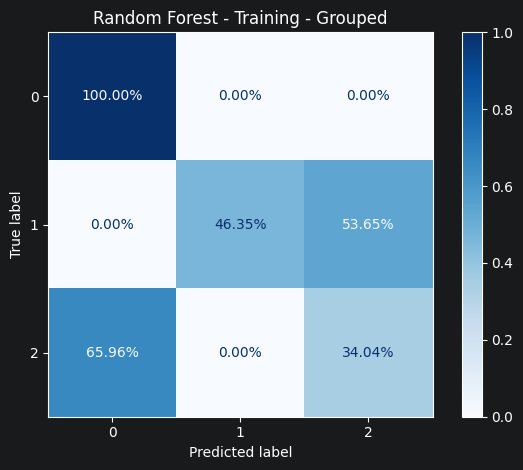

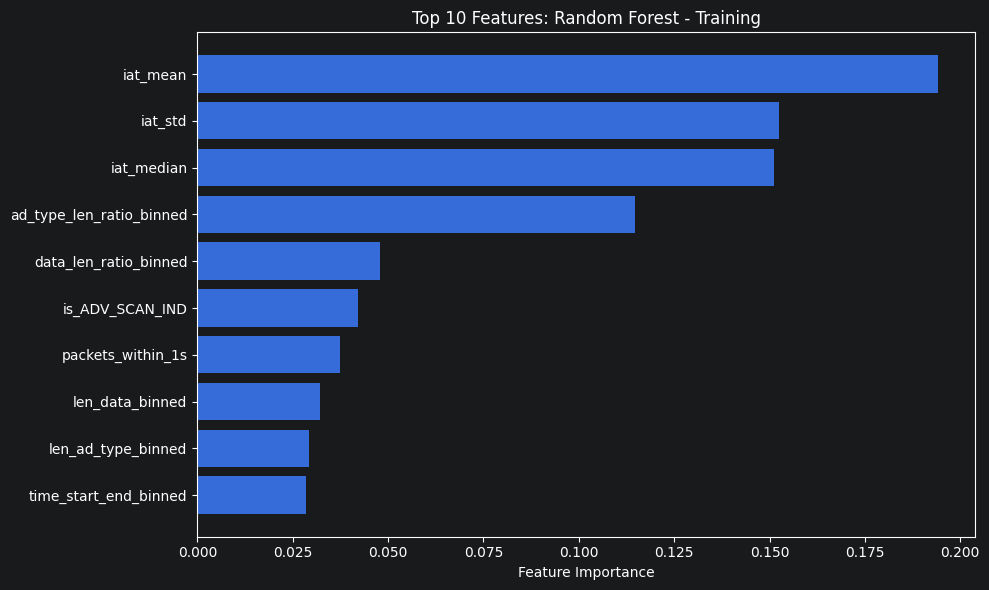

Evaluation on Test Dataset (label=group_label_multi):
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     11223
           1       1.00      0.78      0.88      4587
           2       0.70      0.70      0.70      3376

    accuracy                           0.90     19186
   macro avg       0.87      0.83      0.85     19186
weighted avg       0.90      0.90      0.89     19186



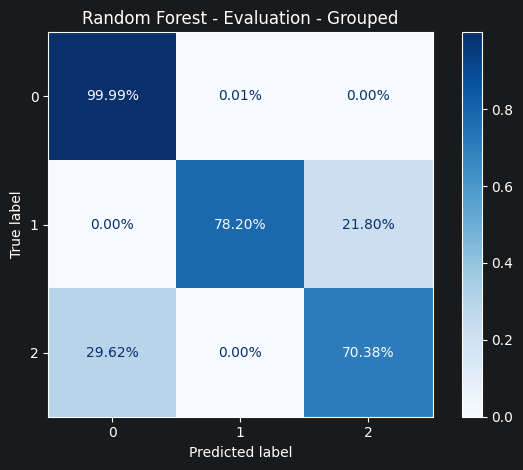

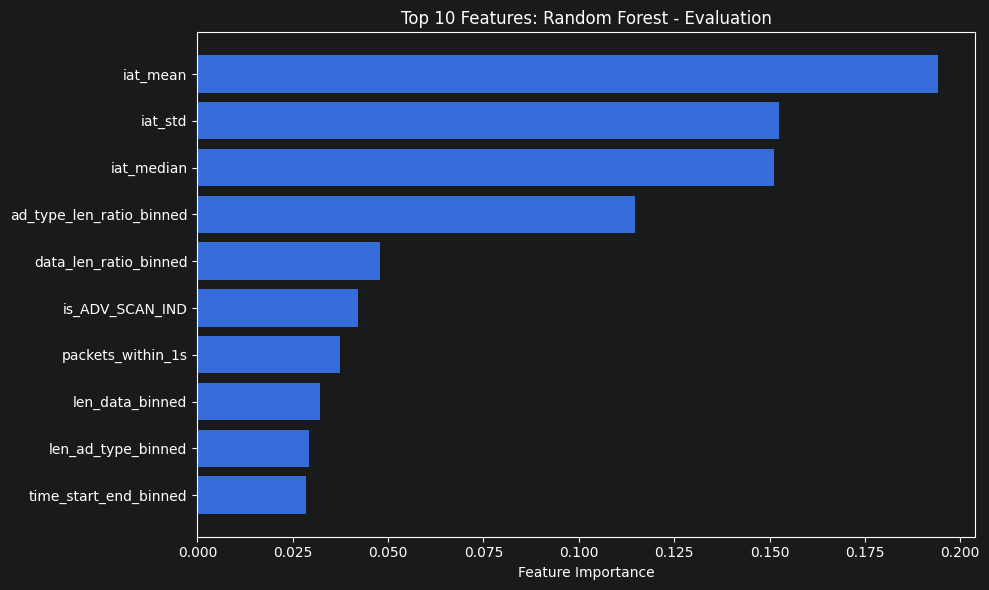


------------------------------------------------------------
STARTING MODEL: Multi-layer Perceptron WITH GROUPED SPLIT MODE: False AND TEST SIZE: 0.3 LABEL: group_label_multi
------------------------------------------------------------

Iteration 1, loss = 0.70873067
Validation score: 0.743002
Iteration 2, loss = 0.53520313
Validation score: 0.786480
Iteration 3, loss = 0.50091330
Validation score: 0.789160
Iteration 4, loss = 0.47249854
Validation score: 0.813580
Iteration 5, loss = 0.44801858
Validation score: 0.822216
Iteration 6, loss = 0.42964533
Validation score: 0.826683
Iteration 7, loss = 0.40385907
Validation score: 0.847826
Iteration 8, loss = 0.38419294
Validation score: 0.850208
Iteration 9, loss = 0.36334230
Validation score: 0.856164
Iteration 10, loss = 0.34579853
Validation score: 0.879690
Iteration 11, loss = 0.32520478
Validation score: 0.871650
Iteration 12, loss = 0.31054896
Validation score: 0.893389
Iteration 13, loss = 0.29538654
Validation score: 0.895473
Iter

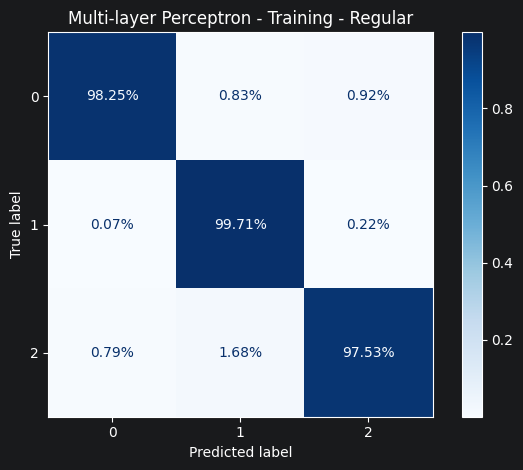


Permutation Importance:
                     Feature  Importance
41  ad_type_len_ratio_binned    0.387318
40     data_len_ratio_binned    0.232905
33        len_ad_type_binned    0.215601
34           len_data_binned    0.206880
1             has_company_id    0.175330
29                   iat_std    0.152884
7                is_SCAN_REQ    0.148645
4                 is_ADV_IND    0.142981
5         is_ADV_NONCONN_IND    0.112092
35     time_start_end_binned    0.109694


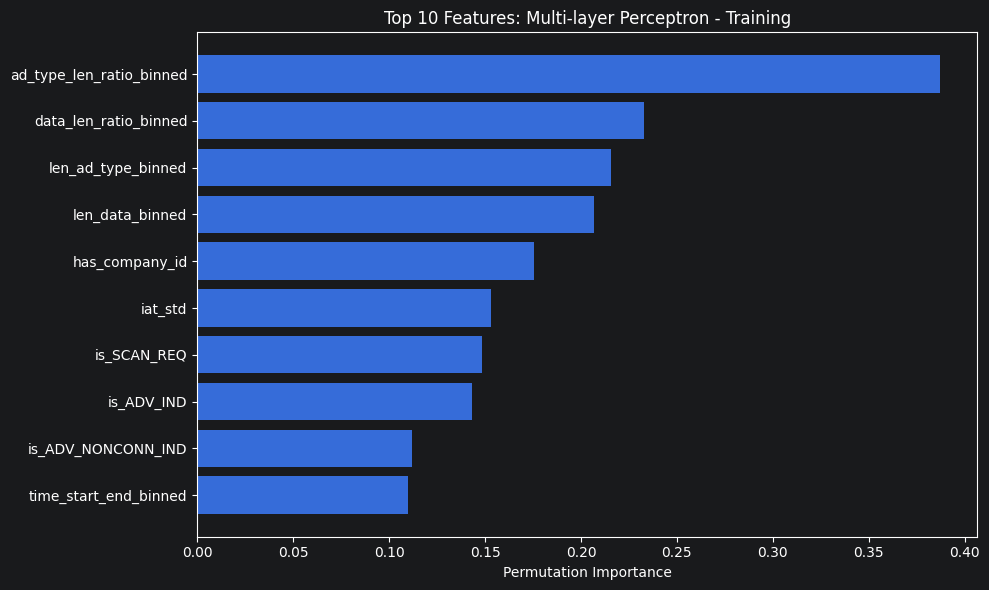

Evaluation on Test Dataset (label=group_label_multi):
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     11223
           1       0.97      1.00      0.98      4587
           2       0.98      0.98      0.98      3376

    accuracy                           0.99     19186
   macro avg       0.98      0.99      0.98     19186
weighted avg       0.99      0.99      0.99     19186



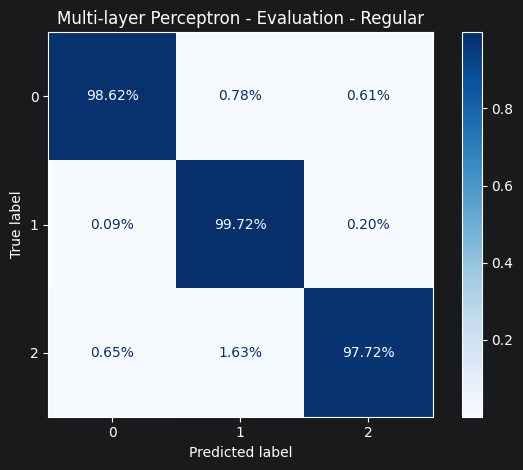


Permutation Importance:
                     Feature  Importance
41  ad_type_len_ratio_binned    0.387318
40     data_len_ratio_binned    0.232905
33        len_ad_type_binned    0.215601
34           len_data_binned    0.206880
1             has_company_id    0.175330
29                   iat_std    0.152884
7                is_SCAN_REQ    0.148645
4                 is_ADV_IND    0.142981
5         is_ADV_NONCONN_IND    0.112092
35     time_start_end_binned    0.109694


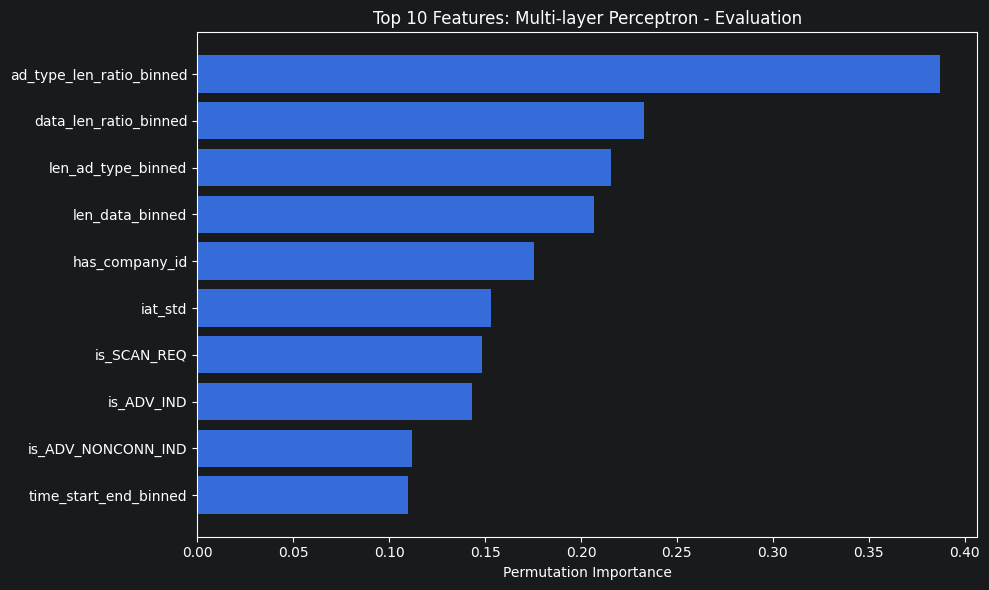


------------------------------------------------------------
STARTING MODEL: Multi-layer Perceptron WITH GROUPED SPLIT MODE: True AND TEST SIZE: 0.3 LABEL: group_label_multi
------------------------------------------------------------

Iteration 1, loss = 0.64811786
Validation score: 0.837167
Iteration 2, loss = 0.40919258
Validation score: 0.854419
Iteration 3, loss = 0.36107085
Validation score: 0.868947
Iteration 4, loss = 0.32646996
Validation score: 0.874395
Iteration 5, loss = 0.29938145
Validation score: 0.875000
Iteration 6, loss = 0.27870382
Validation score: 0.895278
Iteration 7, loss = 0.25980027
Validation score: 0.902240
Iteration 8, loss = 0.24632777
Validation score: 0.900726
Iteration 9, loss = 0.23438015
Validation score: 0.905266
Iteration 10, loss = 0.22109294
Validation score: 0.906477
Iteration 11, loss = 0.20987658
Validation score: 0.914649
Iteration 12, loss = 0.20147765
Validation score: 0.920097
Iteration 13, loss = 0.19201349
Validation score: 0.930993
Itera

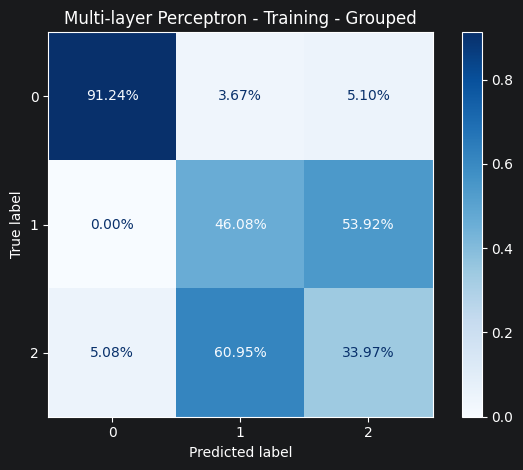


Permutation Importance:
                     Feature  Importance
5         is_ADV_NONCONN_IND    0.195042
7                is_SCAN_REQ    0.189514
41  ad_type_len_ratio_binned    0.187940
40     data_len_ratio_binned    0.092596
29                   iat_std    0.087906
14         packets_within_1s    0.079564
36    delta_end_start_binned    0.073099
33        len_ad_type_binned    0.057688
4                 is_ADV_IND    0.053233
1             has_company_id    0.034037


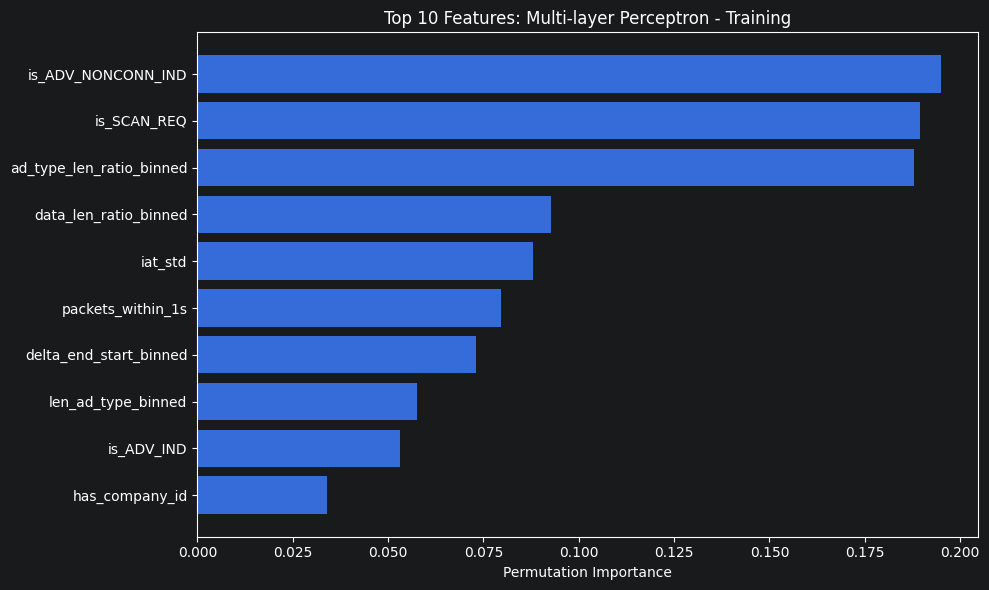

Evaluation on Test Dataset (label=group_label_multi):
              precision    recall  f1-score   support

           0       0.99      0.98      0.98     11223
           1       0.77      0.77      0.77      4587
           2       0.67      0.70      0.69      3376

    accuracy                           0.88     19186
   macro avg       0.81      0.82      0.81     19186
weighted avg       0.88      0.88      0.88     19186



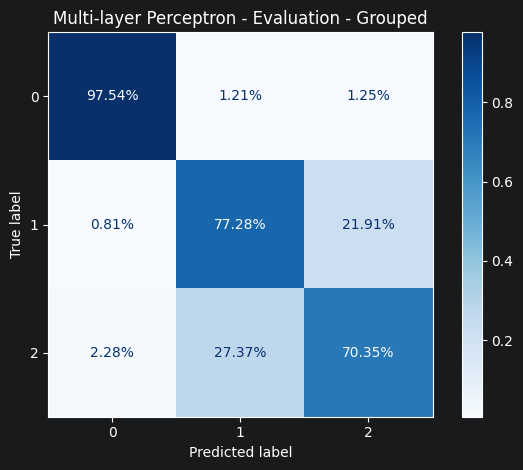


Permutation Importance:
                     Feature  Importance
5         is_ADV_NONCONN_IND    0.195042
7                is_SCAN_REQ    0.189514
41  ad_type_len_ratio_binned    0.187940
40     data_len_ratio_binned    0.092596
29                   iat_std    0.087906
14         packets_within_1s    0.079564
36    delta_end_start_binned    0.073099
33        len_ad_type_binned    0.057688
4                 is_ADV_IND    0.053233
1             has_company_id    0.034037


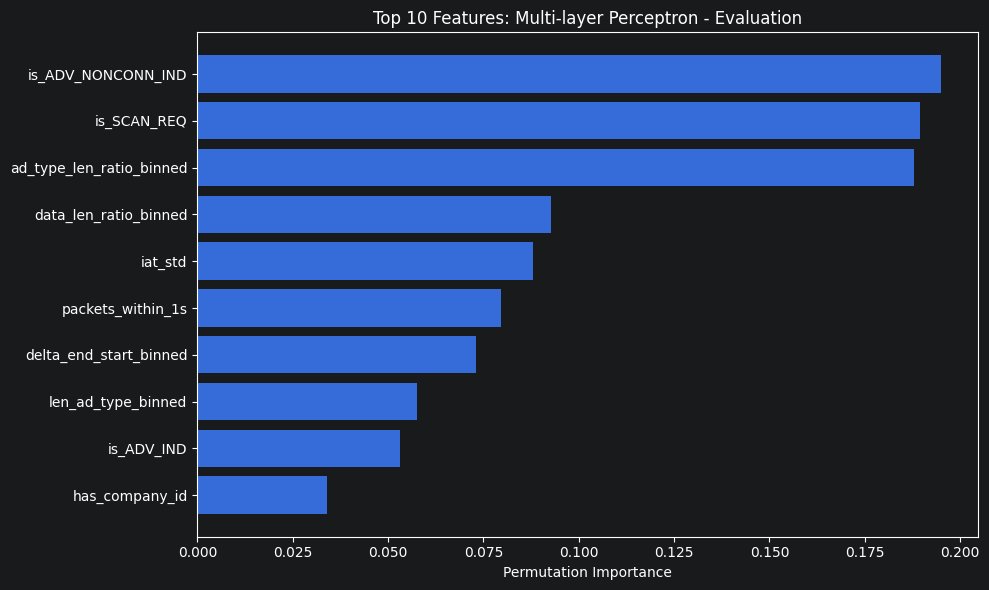


------------------------------------------------------------
STARTING MODEL: Stochastic Gradient Descent WITH GROUPED SPLIT MODE: False AND TEST SIZE: 0.3 LABEL: group_label_multi
------------------------------------------------------------

Train Accuracy: 0.6932
Test Accuracy:  0.6810
CV Accuracy (mean ± std): 0.7124 ± 0.0067
Model Stochastic Gradient Descent               precision    recall  f1-score   support

           0       0.97      0.76      0.85      3367
           1       0.48      0.68      0.56      1376
           2       0.37      0.42      0.40      1013

    accuracy                           0.68      5756
   macro avg       0.61      0.62      0.60      5756
weighted avg       0.75      0.68      0.70      5756



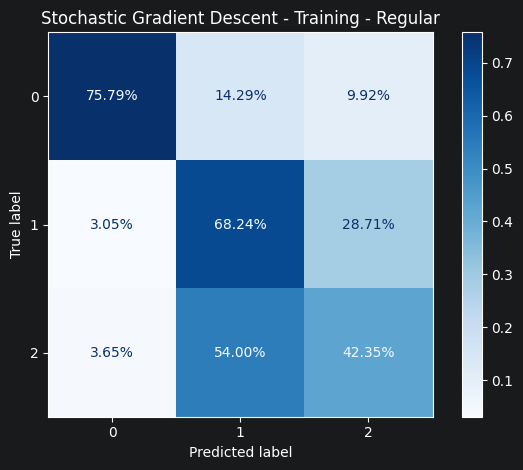


Permutation Importance:
                   Feature  Importance
5       is_ADV_NONCONN_IND    0.171716
4               is_ADV_IND    0.150591
7              is_SCAN_REQ    0.149618
35   time_start_end_binned    0.075434
13  service_data_len_ratio    0.040653
1           has_company_id    0.017755
34         len_data_binned    0.015462
33      len_ad_type_binned    0.015462
15    packets_within_100ms    0.014350
16     packets_within_25ms    0.005733


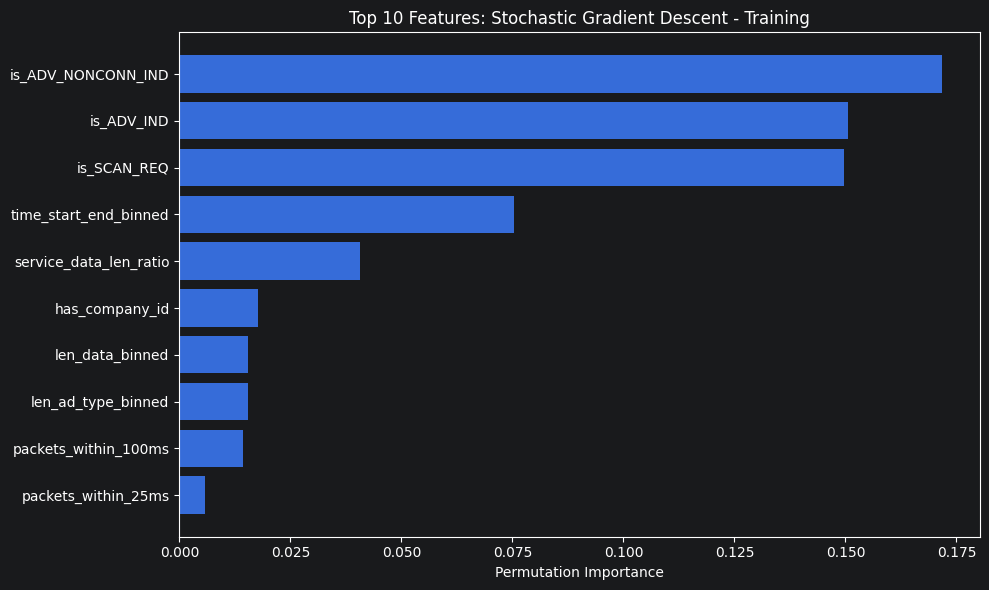

Evaluation on Test Dataset (label=group_label_multi):
              precision    recall  f1-score   support

           0       0.97      0.77      0.86     11223
           1       0.48      0.70      0.57      4587
           2       0.38      0.41      0.40      3376

    accuracy                           0.69     19186
   macro avg       0.61      0.63      0.61     19186
weighted avg       0.75      0.69      0.71     19186



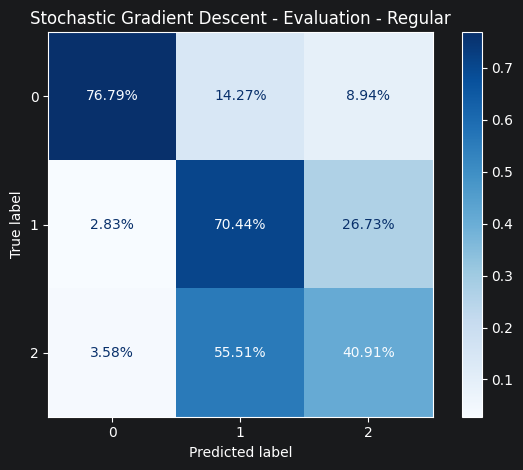


Permutation Importance:
                   Feature  Importance
5       is_ADV_NONCONN_IND    0.171716
4               is_ADV_IND    0.150591
7              is_SCAN_REQ    0.149618
35   time_start_end_binned    0.075434
13  service_data_len_ratio    0.040653
1           has_company_id    0.017755
34         len_data_binned    0.015462
33      len_ad_type_binned    0.015462
15    packets_within_100ms    0.014350
16     packets_within_25ms    0.005733


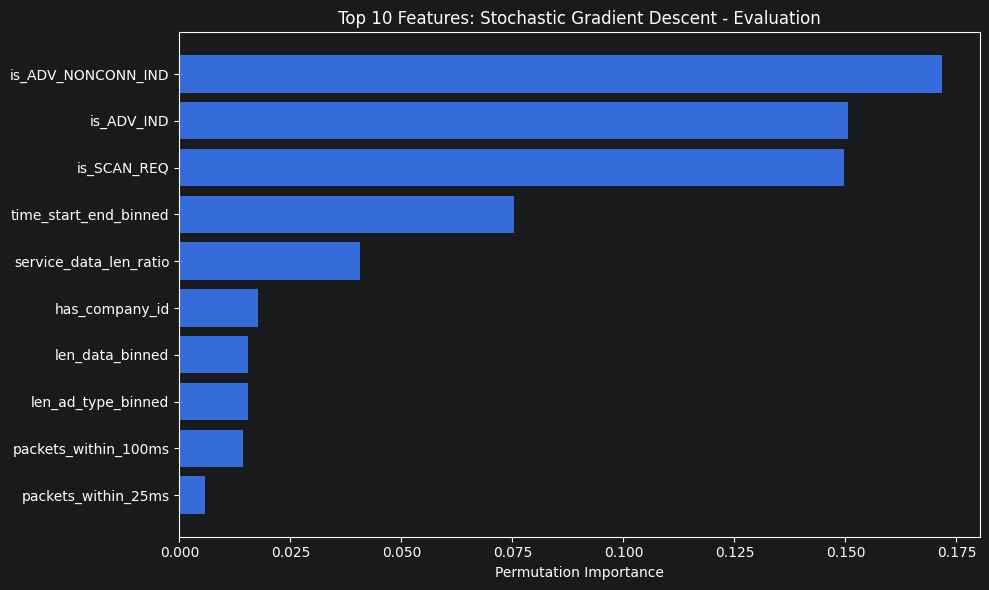


------------------------------------------------------------
STARTING MODEL: Stochastic Gradient Descent WITH GROUPED SPLIT MODE: True AND TEST SIZE: 0.3 LABEL: group_label_multi
------------------------------------------------------------

Train Accuracy: 0.8110
Test Accuracy:  0.4660
CV Accuracy (mean ± std): 0.7230 ± 0.1472
Model Stochastic Gradient Descent               precision    recall  f1-score   support

           0       0.95      0.70      0.80      2590
           1       0.30      0.45      0.36      1864
           2       0.10      0.09      0.09      1516

    accuracy                           0.47      5970
   macro avg       0.45      0.41      0.42      5970
weighted avg       0.53      0.47      0.49      5970



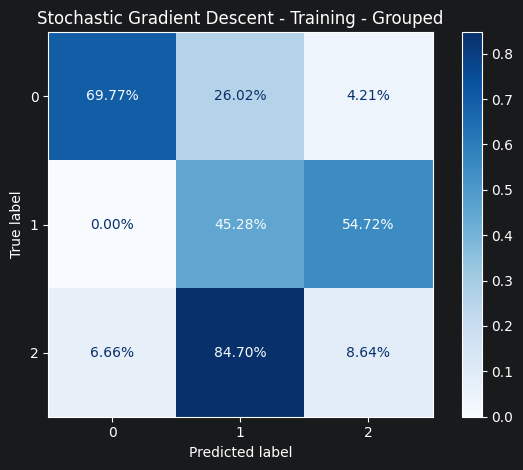


Permutation Importance:
                     Feature  Importance
41  ad_type_len_ratio_binned    0.172362
5         is_ADV_NONCONN_IND    0.141675
35     time_start_end_binned    0.103618
7                is_SCAN_REQ    0.085561
1             has_company_id    0.016717
15      packets_within_100ms    0.013903
13    service_data_len_ratio    0.013434
3                 has_uuid16    0.010653
30                  iat_mean    0.006600
40     data_len_ratio_binned    0.006365


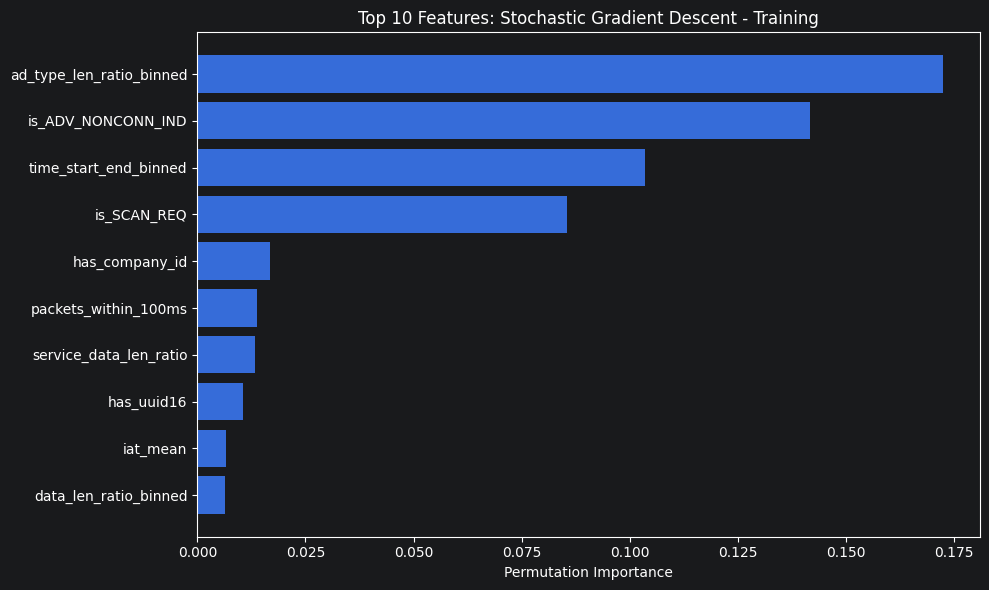

Evaluation on Test Dataset (label=group_label_multi):
              precision    recall  f1-score   support

           0       0.98      0.78      0.87     11223
           1       0.45      0.75      0.56      4587
           2       0.50      0.40      0.45      3376

    accuracy                           0.70     19186
   macro avg       0.64      0.64      0.63     19186
weighted avg       0.77      0.70      0.72     19186



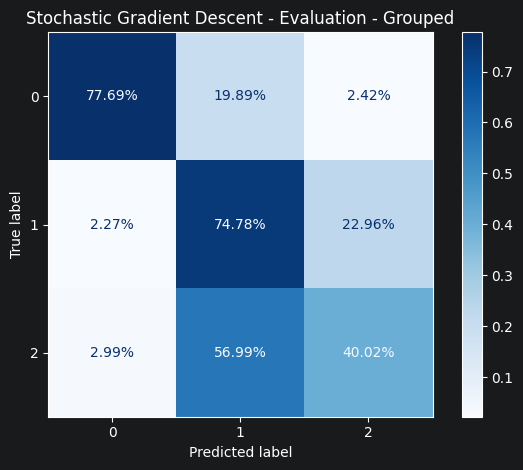


Permutation Importance:
                     Feature  Importance
41  ad_type_len_ratio_binned    0.172362
5         is_ADV_NONCONN_IND    0.141675
35     time_start_end_binned    0.103618
7                is_SCAN_REQ    0.085561
1             has_company_id    0.016717
15      packets_within_100ms    0.013903
13    service_data_len_ratio    0.013434
3                 has_uuid16    0.010653
30                  iat_mean    0.006600
40     data_len_ratio_binned    0.006365


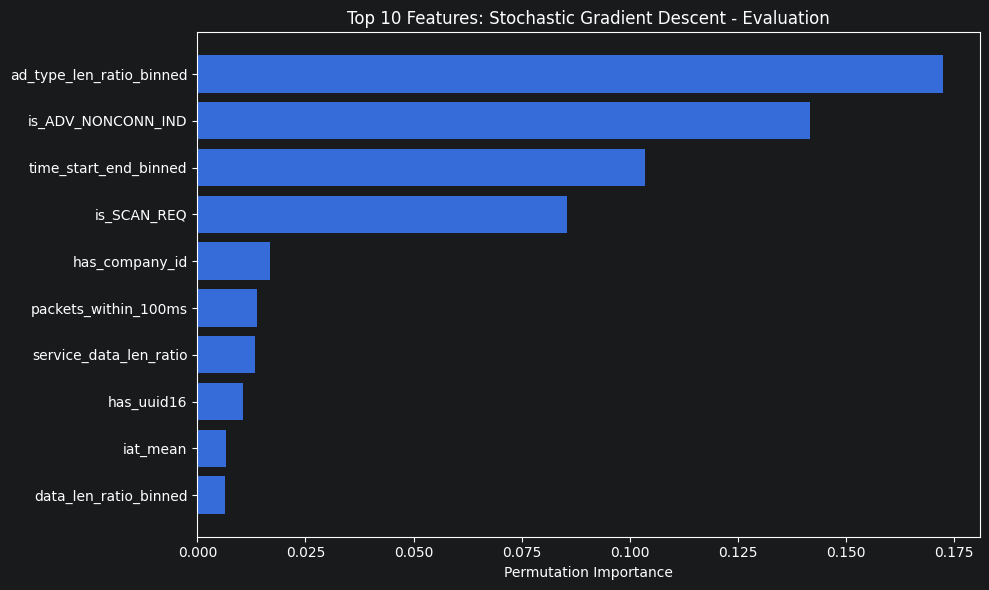

In [52]:
##############################
#        CODE FIELD 6        #
##############################

# Single-file adaptation: train_df_binned_large_balanced and eval_df_binned_balanced currently POINT TO SAME CAPTURE.
# The true evaluation must be via GroupShuffleSplit (sources unseen) done below, NOT via separate location.
# This is suitable for pipeline validation but NOT for cross-location generalization.
# For a proper thesis evaluation collect a 2nd capture (different room/day) and set eval_df to that file.

# Split-mode False = stratified packet shuffle (leakage prone), True = GroupShuffleSplit by source (recommended for RPA)
split_mode_grouped = [False, True]

# Define the datasets to train and evaluate on
# For binary baseline:
df_to_train = train_df_binned_large_balanced
df_to_eval = eval_df_binned_balanced 

# For 3-class multi-group, ensure label column exists:
label_col_binary = 'group_label'
label_col_multi = 'group_label_multi'
use_label = label_col_multi  # binary: label_col_binary (Target vs Noise), multi: label_col_multi (0/1/2)

# Make sure column order matches (important for single-file duplicated data)
if (df_to_train.columns != df_to_eval.columns).any():
    df_to_eval = df_to_eval[df_to_train.columns]

print(f'USING COLUMNS: {list(df_to_train.drop(columns=[c for c in dropped_columns + [label_col_binary,label_col_multi,"group_id","group_label_bin"] if c in df_to_train.columns]).columns)}')
print(f'Training with label={use_label}, distribution: {df_to_train[use_label].value_counts().to_dict()}')
print(f'Eval within-capture distribution: {df_to_eval[use_label].value_counts().to_dict()} (same capture - use GroupShuffleSplit for honest estimate)')

# Loop over defined models
for model_name in model_dict.keys():
    for split_mode in split_mode_grouped:
        model_to_run = model_dict[model_name]
        df_dropped = df_to_train.drop(columns=[c for c in dropped_columns + [label_col_binary,label_col_multi,'group_id','group_label_bin'] if c in df_to_train.columns])

        print(f'\n------------------------------------------------------------')
        print(f'STARTING MODEL: {model_name} WITH GROUPED SPLIT MODE: {split_mode} AND TEST SIZE: {test_param} LABEL: {use_label}')
        print(f'------------------------------------------------------------\n')
        
        X_train, X_test, y_train, y_test = split_data(
            base_df = df_to_train,
            X = df_dropped,
            y = df_to_train[use_label],
            test_size = test_param,
            split_mode_group=split_mode
        )

        model, y_pred = fit_and_predict_model(
            model = model_to_run,
            X_train = X_train,
            X_test = X_test,
            y_train = y_train,
            y_test = y_test
        )

        print(f'Model {model_name}', classification_report(y_test, y_pred, zero_division=0))

        create_matrix(
            model = model,
            y_test = y_test,
            y_pred = y_pred,
            model_name = model_name,
            split_mode=split_mode,
            model_type='Training',
        )

        model_feature_importance(
            model=model,
            X_test=X_test,
            y_test=y_test,
            model_name=model_name,
            model_type='Training'
        )

        # For single-file, eval_df is same capture -> use label_col
        evaluate_model(
            model=model,
            model_name=model_name,
            eval_df=df_to_eval,
            split_mode=split_mode,
            balance_mode=True,
            label_col=use_label
        )

        model_feature_importance(
            model=model,
            X_test=X_test,
            y_test=y_test,
            model_name=model_name,
            model_type='Evaluation'
        )


## Learning Curves

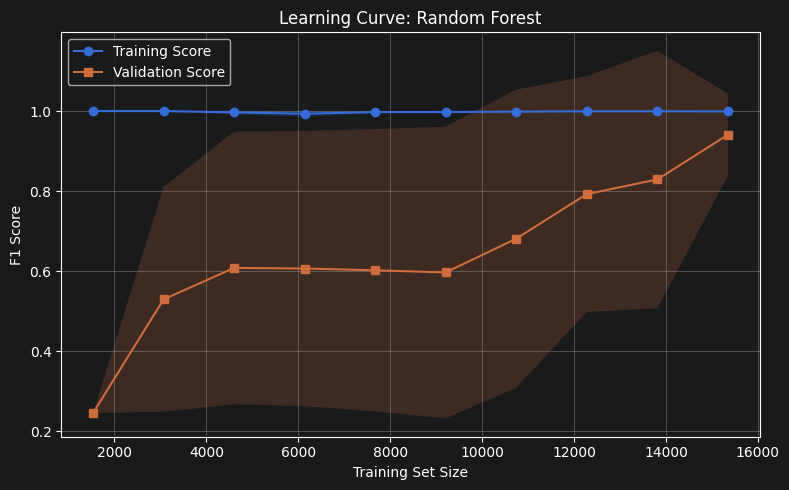

In [53]:
##############################
#        CODE FIELD 7        #
##############################

X = train_df_binned_large_balanced.drop(columns=[c for c in dropped_columns + ['group_label','group_label_multi','group_label_bin','group_id'] if c in train_df_binned_large_balanced.columns])
y = train_df_binned_large_balanced['group_label_multi']  # use group_label for binary

# Create learning curve including cross-validation
train_sizes, train_scores, val_scores = learning_curve(
    estimator=RandomForestClassifier(random_state=1, class_weight='balanced', n_estimators=50, min_samples_split=10, min_samples_leaf=3, min_weight_fraction_leaf=0.002),
    X=X,
    y=y,
    cv=5,
    scoring='f1_macro',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

# Compute means and std deviations
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, label='Training Score', marker='o')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)

plt.plot(train_sizes, val_mean, label='Validation Score', marker='s')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2)

plt.xlabel('Training Set Size')
plt.ylabel('F1 Score')
plt.title(f'Learning Curve: Random Forest')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

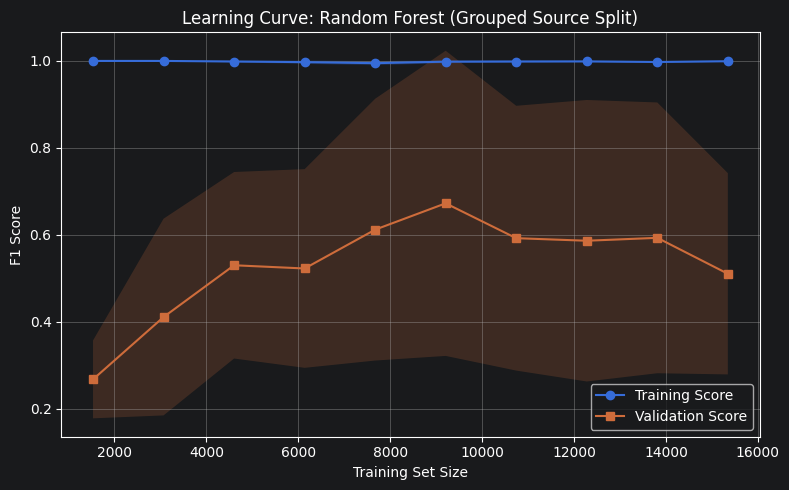

In [54]:
##############################
#        CODE FIELD 8        #
##############################

# Prepare X, y, and groups (source-based grouping)
X = train_df_binned_large_balanced.drop(columns=[c for c in dropped_columns + ['group_label','group_label_multi','group_label_bin','group_id'] if c in train_df_binned_large_balanced.columns])
y = train_df_binned_large_balanced['group_label_multi']  # use group_label for binary
groups = train_df_binned_large_balanced['source'].fillna('missing').astype(str)

# Group-aware cross-validation
cv = GroupKFold(n_splits=5)

train_sizes, train_scores, val_scores = learning_curve(
    estimator=RandomForestClassifier(random_state=1, class_weight='balanced', n_estimators=50, min_samples_split=10, min_samples_leaf=3, min_weight_fraction_leaf=0.002),
    X=X,
    y=y,
    groups=groups,
    cv=cv,
    scoring='f1_macro',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

# Compute means and std deviations
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

# Plotting the curve
plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, label='Training Score', marker='o')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)

plt.plot(train_sizes, val_mean, label='Validation Score', marker='s')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2)

plt.xlabel('Training Set Size')
plt.ylabel('F1 Score')
plt.title('Learning Curve: Random Forest (Grouped Source Split)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Unsupervised Learning

In [55]:
# Define aggregate features for unsupervised learning
# The paramter min_packets filters out any source addresses with less packets in total than the defined value
def aggregate_device_features(df, min_packets: int):
    counts = df['source'].value_counts()

    valid_sources = counts[counts >= min_packets].index
    print(f"Number of sources with packet count above {min_packets}: {len(valid_sources)}")
    df_filtered = df[df['source'].isin(valid_sources)]
                     
    grouped = df_filtered.groupby('source').agg({
        'is_ADV_EXT_IND': ['mean', 'std', 'min', 'max'],
        'is_ADV_IND': ['mean', 'std', 'min', 'max'],
        'is_ADV_NONCONN_IND': ['mean', 'std', 'min', 'max'],
        'is_ADV_SCAN_IND': ['mean', 'std', 'min', 'max'],
        'is_AUX_ADV_IND': ['mean', 'std', 'min', 'max'],
        'is_SCAN_REQ': ['mean', 'std', 'min', 'max'],
        'packets_within_1s': ['mean', 'std', 'min', 'max'],
        'packets_within_100ms': ['mean', 'std', 'min', 'max'],
        'packets_within_25ms': ['mean', 'std', 'min', 'max'],
        'packets_within_2ms': ['mean', 'std', 'min', 'max'],
        'coactive_packets_in_bin': ['mean', 'std', 'min', 'max'],
        'coactive_sources_in_bin': ['mean', 'std', 'min', 'max'],
        'coactive_density': ['mean', 'std', 'min', 'max'],
        'payload_sync_in_bin': ['mean', 'std', 'min', 'max'],
        'payload_sync_density': ['mean', 'std', 'min', 'max'],
        'iat_median': ['mean', 'std', 'min', 'max'],
        'iat_std': ['mean', 'std', 'min', 'max'],
        'iat_deviation': ['mean', 'std', 'min', 'max'],
        'len_ad_type_binned': ['mean', 'std', 'min', 'max'],
        'len_data_binned': ['mean', 'std', 'min', 'max'],
        'time_start_end_binned': ['mean', 'std', 'min', 'max'],
        'delta_end_start_binned': ['mean', 'std', 'min', 'max'],
        'delta_start_start_binned': ['mean', 'std', 'min', 'max'],
        'packet_send_freq_binned': ['mean', 'std', 'min', 'max'],
        'time_to_next_binned': ['mean', 'std', 'min', 'max'],
        'ad_type_len_ratio_binned': ['mean', 'std', 'min', 'max'],
        'service_data_len_ratio': ['mean', 'std', 'min', 'max'],
        'data_len_ratio_binned': ['mean', 'std', 'min', 'max'],
    })

    # Ensure the grouped columns are named nicely
    grouped.columns = ['_'.join(col).strip() for col in grouped.columns.values]
    grouped.reset_index(inplace=True)
    return grouped

In [56]:
def run_k_means(X_scaled, cluster_size: int = 2):
    init_centroids, _ = kmeans_plusplus(X_scaled, n_clusters=cluster_size, random_state=1)
    clusterer = KMeans(n_clusters=cluster_size, init=init_centroids, n_init=1, random_state=1)
    cluster_labels = clusterer.fit_predict(X_scaled)

    return cluster_labels

def run_birch(X_scaled, cluster_size: int = 2):
    birch_clusterer = Birch(n_clusters=cluster_size)
    cluster_labels = birch_clusterer.fit_predict(X_scaled)

    return cluster_labels

def run_bk_means(X_scaled, cluster_size: int = 2):
    clusterer = BisectingKMeans(n_clusters=cluster_size, random_state=1)
    cluster_labels = clusterer.fit_predict(X_scaled)

    return cluster_labels

In [57]:
def evaluate_metrics(y_true, model_result, num: int):
    ari = adjusted_rand_score(y_true, model_result) # similarity of the two assignments
    homogeneity = metrics.homogeneity_score(y_true, model_result) # each cluster contains only members of a single class
    completeness = metrics.completeness_score(y_true, model_result) # all members of a given class are assigned to the same cluster
    v_score = metrics.v_measure_score(y_true, model_result) # The V-measure is actually equivalent to the mutual information
    print(f'EVAL OF SOURCES WITH AT LEAST: {num} PACKETS') 
    print(f'ARI: {ari:.4f}')
    print(f'HOMOGENEITY: {homogeneity:.4f}')
    print(f'COMPLETENESS: {completeness:.4f}')
    print(f'V SCORE: {v_score:.4f}\n')

    return ari, homogeneity, completeness, v_score

In [58]:
##############################
#        CODE FIELD 9        #
##############################

# Define dictionaries to keep track of the best performing paramteres
max_dict_k_means = {'max_ari': 0, 'max_ari_num': 0, 'max_ari_cluster': 0, 'max_v_score': 0, 'max_v_score_num': 0, 'max_v_score_cluster': 0}
max_dict_birch = {'max_ari': 0, 'max_ari_num': 0, 'max_v_score': 0, 'max_v_score_num': 0}
max_dict_bk_means = {'max_ari': 0, 'max_ari_num': 0, 'max_v_score': 0, 'max_v_score_num': 0}

# Choose the model to run: kmeans, birch, bk_means
# ADJUST:
algorithm_to_run = 'kmeans' # kmeans, birch, bk_means
# For multi-group: k=3 (noise/G1/G2) vs binary k=2

# Use the loop below to find the best-performing numbers
# Use the specific number below to run the best version ([36] for kmeans, [42] for birch and [38] for BisectingKMeans)
# Using only the best-performing number ensures the parameters for plotting later are set correctly
# ADJUST:
for num in [36]:
    agg_df = aggregate_device_features(eval_df_binned_balanced, num)

    label_lookup = eval_df_binned_balanced[['source', 'group_label','group_label_multi','group_id']].drop_duplicates()
    agg_df = agg_df.merge(label_lookup, on='source', how='left')

    X = agg_df.drop(columns=['source', 'group_label'])
    print(f'Length: {len(X)}', f'Num: {num}')

    y_true = agg_df['group_label_multi'].values if 'group_label_multi' in agg_df.columns else agg_df['group_label'].values
    print(f'y_true distribution: {dict(zip(*np.unique(y_true, return_counts=True)))}')

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    if algorithm_to_run == 'kmeans' or algorithm_to_run == 'all':
        # For KMeans, try cluster sizes 2 to 10 per num
        for cluster_size in [3]: # use [2] for binary, [3] for multi-group; sweep 2..5 if needed
            k_means_labels = run_k_means(X_scaled, cluster_size)
            k_means_ari, k_means_homogeneity, k_means_completeness, k_means_v_score = evaluate_metrics(y_true, k_means_labels, num)

            if k_means_ari > float(max_dict_k_means['max_ari']):
                max_dict_k_means['max_ari'] = f'{k_means_ari:.4f}'
                max_dict_k_means['max_ari_num'] = num
                max_dict_k_means['max_ari_cluster'] = cluster_size
            if k_means_v_score > float(max_dict_k_means['max_v_score']):
                max_dict_k_means['max_v_score'] = f'{k_means_v_score:.4f}'
                max_dict_k_means['max_v_score_num'] = num
                max_dict_k_means['max_v_score_cluster'] = cluster_size

    if algorithm_to_run == 'birch' or algorithm_to_run == 'all':
        # Run Birch model
        birch_labels = run_birch(X_scaled=X_scaled, cluster_size=cluster_size)
        birch_ari, birch_homogeneity, birch_completeness, birch_v_score = evaluate_metrics(y_true, birch_labels, num)

        if birch_ari > float(max_dict_birch['max_ari']):
            max_dict_birch['max_ari'] = f'{birch_ari:.4f}'
            max_dict_birch['max_ari_num'] = num
        if birch_v_score > float(max_dict_birch['max_v_score']):
            max_dict_birch['max_v_score'] = f'{birch_v_score:.4f}'
            max_dict_birch['max_v_score_num'] = num
    
    if algorithm_to_run == 'bk_means' or algorithm_to_run == 'all':
        # Run BisectingKMeans model
        bk_means_labels = run_bk_means(X_scaled=X_scaled, cluster_size=cluster_size)
        bk_means_ari, bk_means_homogeneity, bk_means_completeness, bk_means_v_score = evaluate_metrics(y_true, bk_means_labels, num)

        if bk_means_ari > float(max_dict_bk_means['max_ari']):
            max_dict_bk_means['max_ari'] = f'{bk_means_ari:.4f}'
            max_dict_bk_means['max_ari_num'] = num
        if bk_means_v_score > float(max_dict_bk_means['max_v_score']):
            max_dict_bk_means['max_v_score'] = f'{bk_means_v_score:.4f}'
            max_dict_bk_means['max_v_score_num'] = num
print('------------------------------------------------')
print(f'FINAL_DICT K_MEANS: {max_dict_k_means}')
print(f'FINAL_DICT BIRCH: {max_dict_birch}')
print(f'FINAL_DICT BK_MEANS: {max_dict_bk_means}')

Number of sources with packet count above 36: 31
Length: 31 Num: 36
y_true distribution: {np.int64(0): np.int64(20), np.int64(1): np.int64(5), np.int64(2): np.int64(6)}
EVAL OF SOURCES WITH AT LEAST: 36 PACKETS
ARI: 0.0928
HOMOGENEITY: 0.0902
COMPLETENESS: 0.1017
V SCORE: 0.0956

------------------------------------------------
FINAL_DICT K_MEANS: {'max_ari': '0.0928', 'max_ari_num': 36, 'max_ari_cluster': 3, 'max_v_score': '0.0956', 'max_v_score_num': 36, 'max_v_score_cluster': 3}
FINAL_DICT BIRCH: {'max_ari': 0, 'max_ari_num': 0, 'max_v_score': 0, 'max_v_score_num': 0}
FINAL_DICT BK_MEANS: {'max_ari': 0, 'max_ari_num': 0, 'max_v_score': 0, 'max_v_score_num': 0}


In [59]:
##############################
#        CODE FIELD 10       #
##############################

# Adjust labels to match algorithm to analyze
# Also, make sure to run the model in the previous section with only ONE specific num defined
# (i.e. use the commented row 'for num in [x]')
# Otherwise the parameters below will point to the false values
# ADJUST: 
current_labels = k_means_labels # k_means_labels, birch_labels, bk_means_labels
current_algorithm = 'kmeans' # kmeans, birch, bk_means

df_to_analyze = pd.DataFrame({
    'source': agg_df['source'],
    'group_label': agg_df['group_label_multi'] if 'group_label_multi' in agg_df.columns else agg_df['group_label'],
    'kmeans_label': current_labels
})

df_to_analyze['kmeans_label_named'] = ['Group Label B' if label == 0 else 'Group Label A' for label in current_labels]
device_labels_unique = eval_df_binned_balanced[['source', 'labelled_device', 'company_id']].drop_duplicates()
final_df = df_to_analyze.merge(device_labels_unique, on='source', how='left').drop_duplicates(subset='source')

# Filter rows where group_label matches the algorithm label
# Also adjust the comparison logic based on the algorithm, example:
# For KMeans the label is inversed (i.e. target group = 0), for Birch the label matches (i.e. target group = 1)
if current_algorithm in ['kmeans', 'bk_means']:
    mismatching_rows = final_df[final_df['group_label'] == final_df['kmeans_label']]
    matching_rows = final_df[final_df['group_label'] != final_df['kmeans_label']]
else:
    mismatching_rows = final_df[final_df['group_label'] != final_df['kmeans_label']]
    matching_rows = final_df[final_df['group_label'] == final_df['kmeans_label']]

# Count how often each labelled_device appears in the matched rows
device_mismatch_counts_by_device = Counter(mismatching_rows['labelled_device'])
device_match_counts_by_device = Counter(matching_rows['labelled_device'])

device_mismatch_counts = Counter(zip(mismatching_rows['labelled_device'], mismatching_rows['company_id']))
device_match_counts = Counter(zip(matching_rows['labelled_device'], matching_rows['company_id']))

print(f'Length final list: {len(final_df)}')
print('---------------')
print('False labels by device: \n', device_mismatch_counts_by_device)
print('---------------')
print('Correct labels by device: \n', device_match_counts_by_device)
print('---------------')
print('False labels detailed: \n', device_mismatch_counts)
print('---------------')
print('Correct label detailed: \n', device_match_counts)

Length final list: 31
---------------
False labels by device: 
 Counter({'empty': 14, 'Phone': 4})
---------------
Correct labels by device: 
 Counter({'Phone': 6, 'empty': 3, 'AirTag': 2, 'Buds': 2})
---------------
False labels detailed: 
 Counter({('empty', 'Undefined'): 8, ('empty', 'Apple, Inc.'): 6, ('Phone', 'Undefined'): 4})
---------------
Correct label detailed: 
 Counter({('Phone', 'Undefined'): 6, ('AirTag', 'Apple, Inc.'): 2, ('Buds', 'Samsung Electronics Co. Ltd.'): 2, ('empty', 'Samsung Electronics Co. Ltd.'): 1, ('empty', 'Undefined'): 1, ('empty', 'Apple, Inc.'): 1})


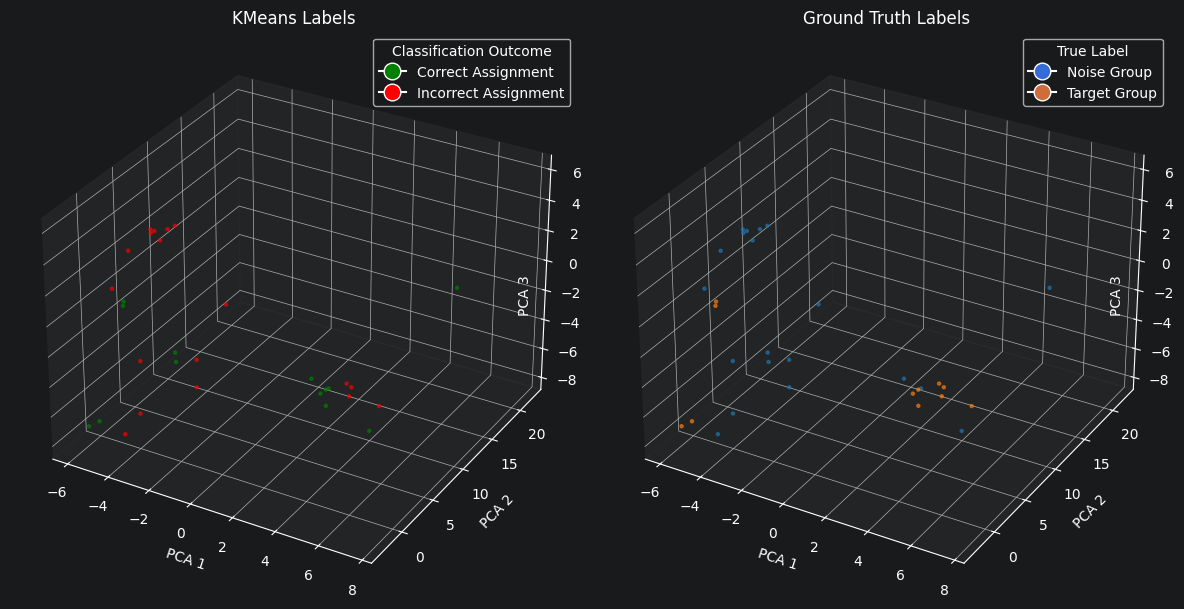

In [60]:
##############################
#       CODE FIELD 11.1      #
##############################

# Define the reduction algorithm and use the correct labels (depending on which model to analyze)
pca = PCA(n_components=3)
X_3d = pca.fit_transform(X_scaled)
# ADJUST:
labels_to_plot = k_means_labels # k_means_labels, birch_labels, bk_means_labels

# Change labels here to the algorithm you are trying to plot
colors = []
for km, yt in zip(labels_to_plot, y_true):
    # Depending on the algorithm, the labels will either match (i.e. target = 1) or not (target = 0)
    # The problem is that you can't control which cluster is assigned which label
    # Therefore, change the logic statement based on the current algorithm
    if current_algorithm in ['kmeans', 'bk_means']:
        if km != yt:
            colors.append('green')
        elif km == yt:
            colors.append('red')
    else:
        if km != yt:
            colors.append('red')
        elif km == yt:
            colors.append('green')


y_true_named = ['Noise Group' if label == 0 else 'Target Group' for label in y_true]
fig = plt.figure(figsize=(12, 6))

# Left Graph
# Adjust the labels and title according to the current model you are running
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.scatter(X_3d[:, 0], X_3d[:, 1], X_3d[:, 2], c=colors, alpha=0.6, s=5)
# ADJUST:
ax1.set_title('KMeans Labels') # KMeans, Birch, BisectingKMeans
ax1.set_xlabel('PCA 1')
ax1.set_ylabel('PCA 2')

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Correct Assignment', markerfacecolor='green', markersize=12),
    Line2D([0], [0], marker='o', color='w', label='Incorrect Assignment', markerfacecolor='red', markersize=12),
]
ax1.legend(handles=legend_elements, title='Classification Outcome')

# Right Graph
# Adjust the labels and title according to the current model you are running
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
group_colors = {
    'Noise Group': 'tab:blue',  
    'Target Group': 'tab:orange' 
}
for group in set(y_true_named):
    idx = [i for i, label in enumerate(y_true_named) if label == group]
    ax2.scatter(X_3d[idx, 0], X_3d[idx, 1], X_3d[idx, 2], label=group, alpha=0.6, s=5, color=group_colors[group]) # adjust size depending on density 
ax2.set_title('Ground Truth Labels')
ax2.set_xlabel('PCA 1')
ax2.set_ylabel('PCA 2')

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Noise Group', markerfacecolor='C0', markersize=12),
    Line2D([0], [0], marker='o', color='w', label='Target Group', markerfacecolor='C1', markersize=12),
]
ax2.legend(handles=legend_elements, title='True Label', fontsize=10, title_fontsize=10)

for ax in (ax1, ax2):
    ax.text2D(
        0.92, 0.5, "PCA 3",
        transform=ax.transAxes,
        rotation=90,
        va="bottom",
        ha="right"
    )

plt.tight_layout()
plt.show()


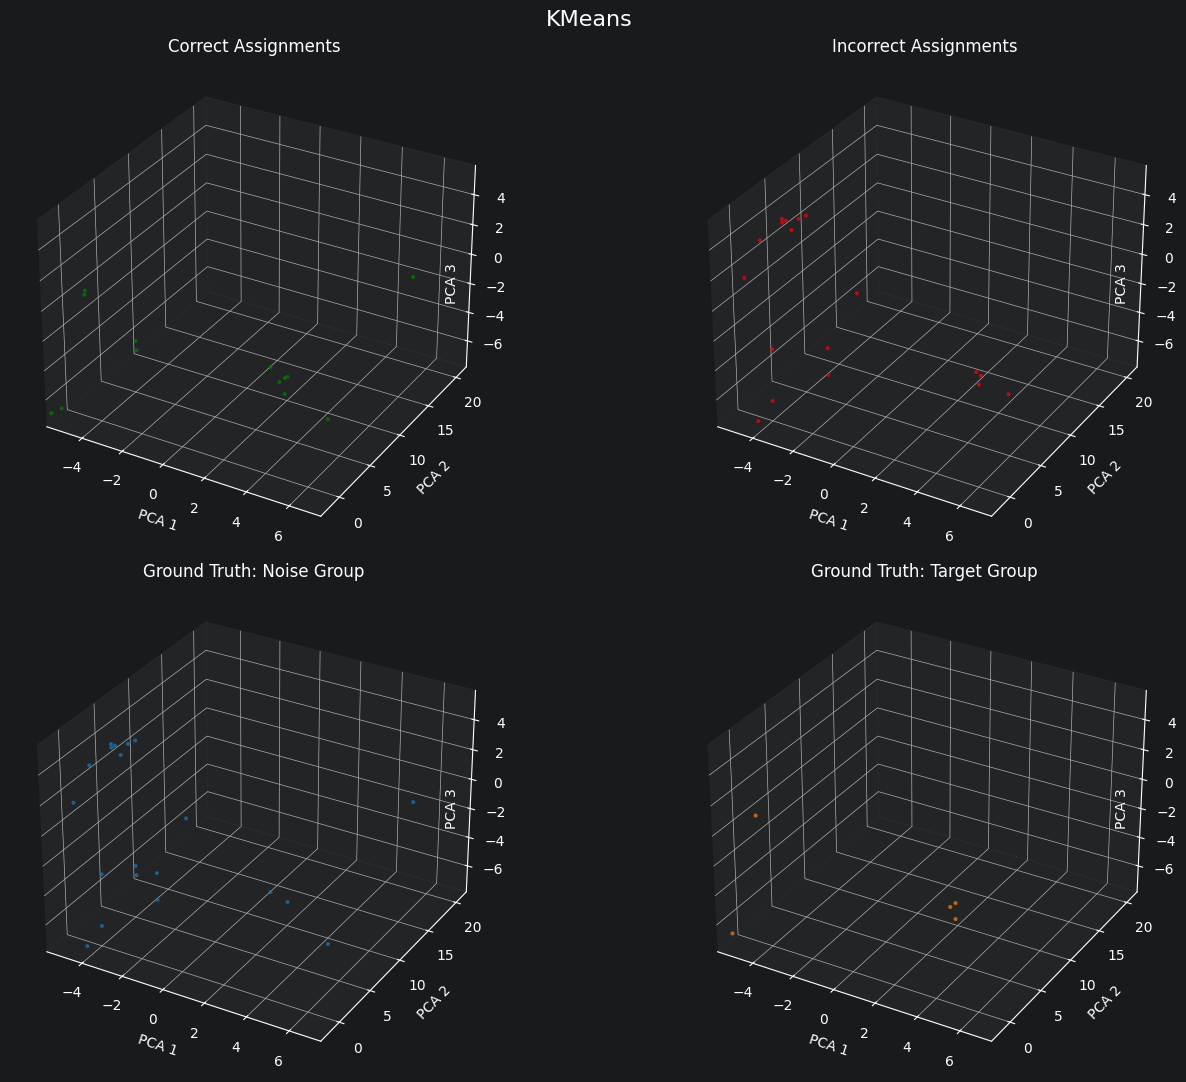

In [61]:
#####################################################
#       CODE FIELD 11.2 - for overlapping data      #
#####################################################

# Define the reduction algorithm
pca = PCA(n_components=3)
X_3d = pca.fit_transform(X_scaled)

# Select the labeling algorithm you want to visualize
# ADJUST
labels_to_plot = k_means_labels # k_means_labels, birch_labels, bk_means_labels

# -------------------------------------------------------
# Determine correct/incorrect assignments for plotting
# -------------------------------------------------------
correct_idx = []
incorrect_idx = []

for i, (pred, truth) in enumerate(zip(labels_to_plot, y_true)):
    # Resolve which numeric label corresponds to positive/negative
    if current_algorithm in ['kmeans', 'bk_means']:
        if pred != truth:
            correct_idx.append(i)
        else:
            incorrect_idx.append(i)
    else:
        # Birch output label mapping differs
        if pred == truth:
            correct_idx.append(i)
        else:
            incorrect_idx.append(i)

# -------------------------------------------------------
# Ground-Truth Groups
# -------------------------------------------------------
noise_idx = [i for i, y in enumerate(y_true) if y == 0]
device_idx = [i for i, y in enumerate(y_true) if y == 1]

# -------------------------------------------------------
# Plot Setup — 2×2 Grid
# -------------------------------------------------------
fig = plt.figure(figsize=(15, 11))

# Common axis limits
x_min, x_max = X_3d[:, 0].min(), X_3d[:, 0].max()
y_min, y_max = X_3d[:, 1].min(), X_3d[:, 1].max()
z_min, z_max = X_3d[:, 2].min(), X_3d[:, 2].max()

# ============================================
# Plot 1 — Correct Assignments
# ============================================
ax1 = fig.add_subplot(2, 2, 1, projection='3d')
ax1.scatter(
    X_3d[correct_idx, 0],
    X_3d[correct_idx, 1],
    X_3d[correct_idx, 2],
    c='green',
    s=4,
    alpha=0.6
)
ax1.set_title("Correct Assignments", fontsize=12)
ax1.set_xlim(x_min, x_max)
ax1.set_ylim(y_min, y_max)
ax1.set_zlim(z_min, z_max)
ax1.set_xlabel("PCA 1")
ax1.set_ylabel("PCA 2")
ax1.set_zlabel("PCA 3", fontsize=10)

# ============================================
# Plot 2 — Incorrect Assignments
# ============================================
ax2 = fig.add_subplot(2, 2, 2, projection='3d')
ax2.scatter(
    X_3d[incorrect_idx, 0],
    X_3d[incorrect_idx, 1],
    X_3d[incorrect_idx, 2],
    c='red',
    s=4,
    alpha=0.6
)
ax2.set_title("Incorrect Assignments", fontsize=12)
ax2.set_xlim(x_min, x_max)
ax2.set_ylim(y_min, y_max)
ax2.set_zlim(z_min, z_max)
ax2.set_xlabel("PCA 1")
ax2.set_ylabel("PCA 2")
ax2.set_zlabel("PCA 3", fontsize=10)

# ============================================
# Plot 3 — Ground Truth Noise Group
# ============================================
ax3 = fig.add_subplot(2, 2, 3, projection='3d')
ax3.scatter(
    X_3d[noise_idx, 0],
    X_3d[noise_idx, 1],
    X_3d[noise_idx, 2],
    c='tab:blue',
    s=4,
    alpha=0.6
)
ax3.set_title("Ground Truth: Noise Group", fontsize=12)
ax3.set_xlim(x_min, x_max)
ax3.set_ylim(y_min, y_max)
ax3.set_zlim(z_min, z_max)
ax3.set_xlabel("PCA 1")
ax3.set_ylabel("PCA 2")
ax3.set_zlabel("PCA 3", fontsize=10)

# ============================================
# Plot 4 — Ground Truth Target Group
# ============================================
ax4 = fig.add_subplot(2, 2, 4, projection='3d')
ax4.scatter(
    X_3d[device_idx, 0],
    X_3d[device_idx, 1],
    X_3d[device_idx, 2],
    c='tab:orange',
    s=4,
    alpha=0.6
)
ax4.set_title("Ground Truth: Target Group", fontsize=12)
ax4.set_xlim(x_min, x_max)
ax4.set_ylim(y_min, y_max)
ax4.set_zlim(z_min, z_max)
ax4.set_xlabel("PCA 1")
ax4.set_ylabel("PCA 2")
ax4.set_zlabel("PCA 3", fontsize=10, labelpad=20)

for ax in (ax1, ax2, ax3, ax4):
    ax.set_zlabel("")
    ax.text2D(
        0.92, 0.5, "PCA 3",
        transform=ax.transAxes,
        rotation=90,
        va="bottom",
        ha="right"
    )

fig.suptitle("KMeans", fontsize="16") 
plt.tight_layout()    
plt.show()


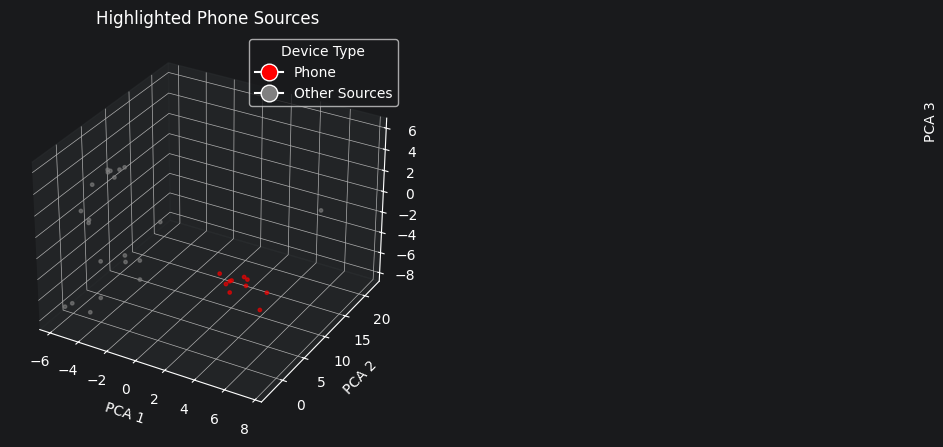

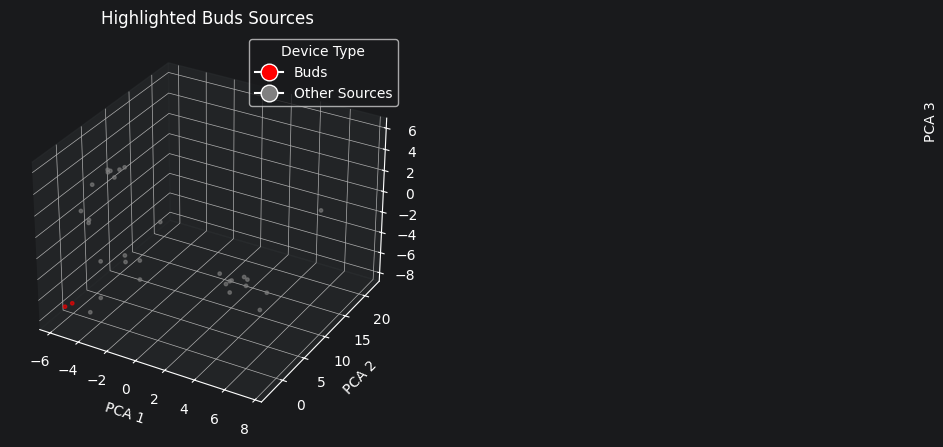

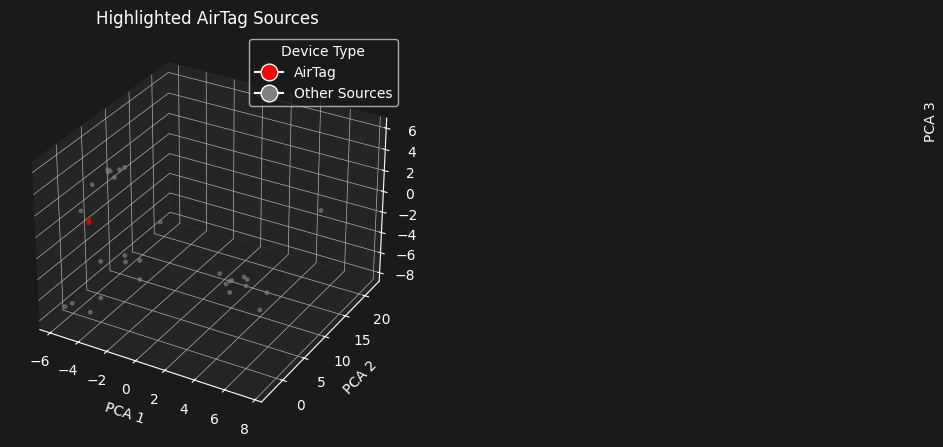

In [62]:
##############################
#        CODE FIELD 12       #
##############################

# PCA projection of the scaled data
pca = PCA(n_components=3)
X_3d = pca.fit_transform(X_scaled)

for device in target_list: 

    # Map the source and labelled_device column onto the evaluation dataset
    mapped_df = agg_df[['source']].copy()
    mapped_df['labelled_device'] = mapped_df['source'].map(
        eval_df_binned_balanced.drop_duplicates('source').set_index('source')['labelled_device']
    )

    # Assign colors: red for the device, gray for all others
    colors = ['red' if device_to_show == device else 'gray' for device_to_show in mapped_df['labelled_device']]

    # Create group labels for ground truth plot
    y_true_named = ['Noise Group' if label == 0 else 'Target Group' for label in y_true]

    # Plotting the graph
    fig = plt.figure(figsize=(12, 6))
    ax1 = fig.add_subplot(1, 2, 1, projection='3d')
    ax1.scatter(X_3d[:, 0], X_3d[:, 1], X_3d[:, 2], c=colors, alpha=0.6, s=6)
    ax1.set_title(f'Highlighted {device} Sources')
    ax1.set_xlabel('PCA 1')
    ax1.set_ylabel('PCA 2')

    # Legend for device types
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label=device, markerfacecolor='Red', markersize=12),
        Line2D([0], [0], marker='o', color='w', label='Other Sources', markerfacecolor='gray', markersize=12),
    ]
    ax1.legend(handles=legend_elements, title='Device Type')

    # Adjust position for each algorithm
    ax1.text2D(
        x=0.17,  
        y=0.6, 
        s="PCA 3", 
        transform=ax.transAxes,
        rotation=90
    )

    plt.tight_layout()
    plt.show()

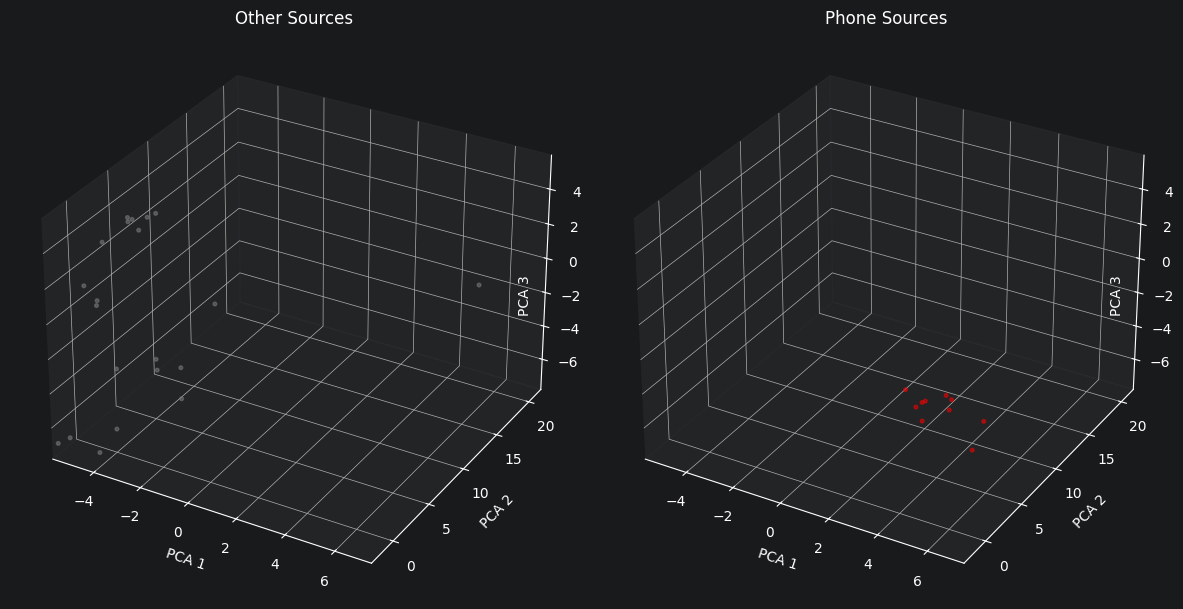

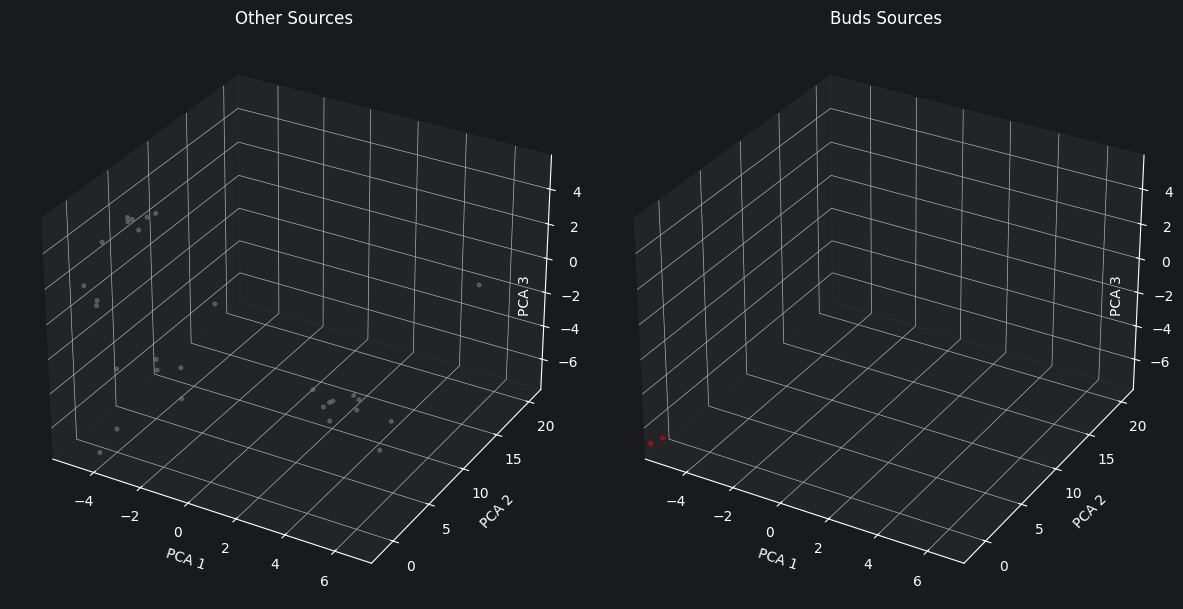

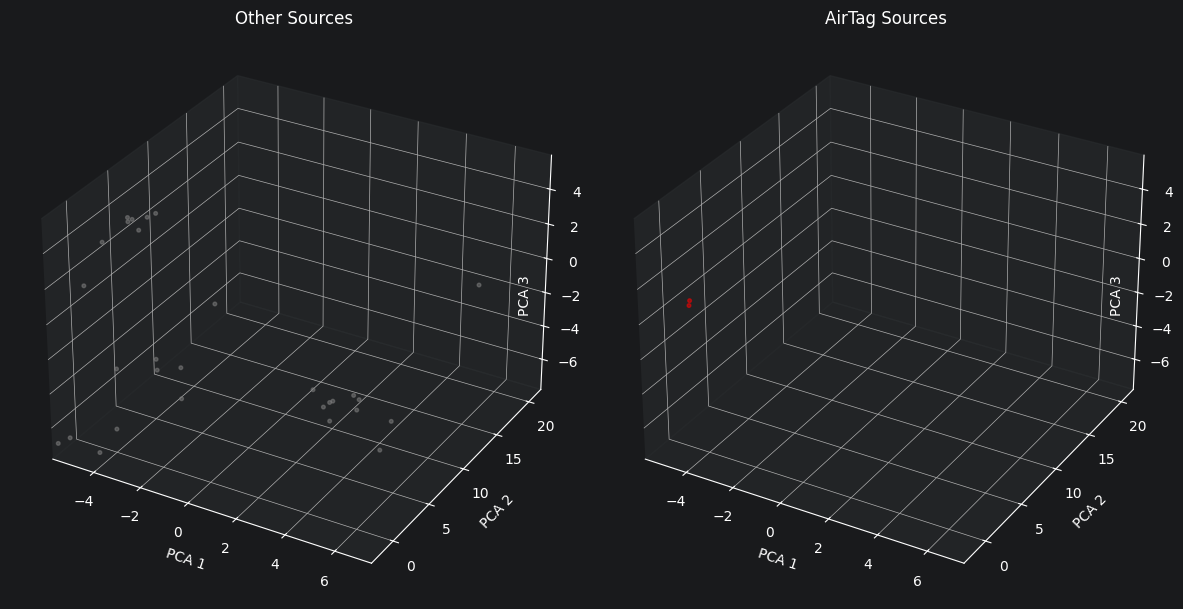

In [63]:
####################################################
#      CODE FIELD 12.2 - for overlapping data      #
####################################################

# PCA projection of the scaled data
pca = PCA(n_components=3)
X_3d = pca.fit_transform(X_scaled)

# get axis limits
x_min, x_max = X_3d[:, 0].min(), X_3d[:, 0].max()
y_min, y_max = X_3d[:, 1].min(), X_3d[:, 1].max()
z_min, z_max = X_3d[:, 2].min(), X_3d[:, 2].max()

for device in target_list:
    # Map the source and labelled_device columns onto the evaluation dataset
    mapped_df = agg_df[['source']].copy()
    mapped_df['labelled_device'] = mapped_df['source'].map(
        eval_df_binned_balanced.drop_duplicates('source').set_index('source')['labelled_device']
    )

    # Identify indices for target group (device_to_show) and noise (all others)
    device_idx = [i for i, label in enumerate(mapped_df['labelled_device']) if label == device]
    noise_idx = [i for i, label in enumerate(mapped_df['labelled_device']) if label != device]
    
    fig = plt.figure(figsize=(12, 6))  

    # ----------------------
    # Subplot 1: Noise Group
    # ----------------------
    ax1 = fig.add_subplot(1, 2, 1, projection='3d')
    ax1.scatter(X_3d[noise_idx, 0], X_3d[noise_idx, 1], X_3d[noise_idx, 2],
                c='gray', alpha=0.5, s=7)
    ax1.set_title("Other Sources")
    ax1.set_xlabel('PCA 1')
    ax1.set_ylabel('PCA 2')

    # ----------------------
    # Subplot 2: Target Group
    # ----------------------
    ax2 = fig.add_subplot(1, 2, 2, projection='3d')
    ax2.scatter(X_3d[device_idx, 0], X_3d[device_idx, 1], X_3d[device_idx, 2],
                c='red', alpha=0.5, s=7)
    ax2.set_title(f"{device} Sources")
    ax2.set_xlabel('PCA 1')
    ax2.set_ylabel('PCA 2')

    for ax in (ax1, ax2):
        # set z-axis label
        ax.set_zlabel("") 
        ax.text2D(
            0.92, 0.5, "PCA 3",
            transform=ax.transAxes,
            rotation=90,
            va="bottom",
            ha="right"
        )
        # set axis limits
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        ax.set_zlim(z_min, z_max)

    plt.tight_layout()
    plt.show()





Correct/Incorrect assignments per device:
 correct_assignment  Incorrect  Correct
labelled_device                       
AirTag                      0        2
Buds                        0        2
Phone                       0       10
empty                       3       14


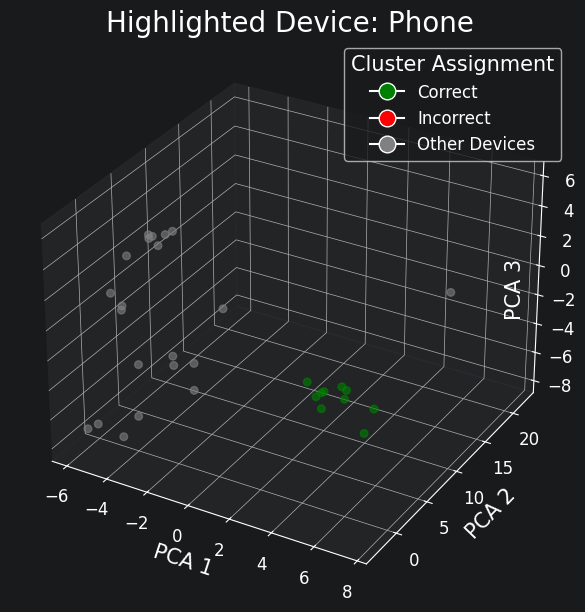

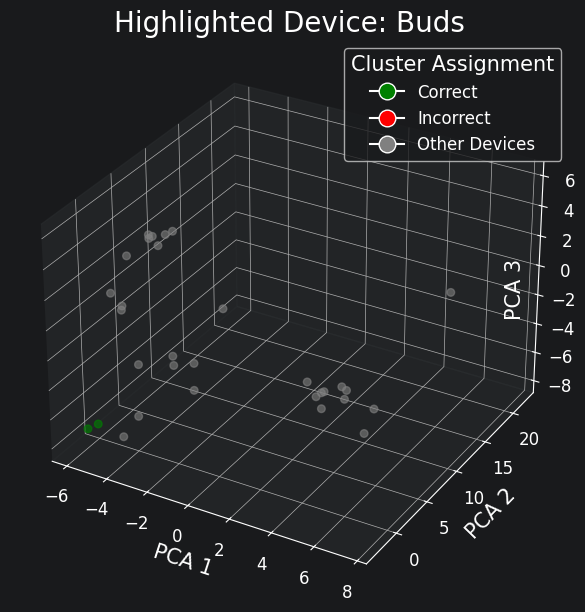

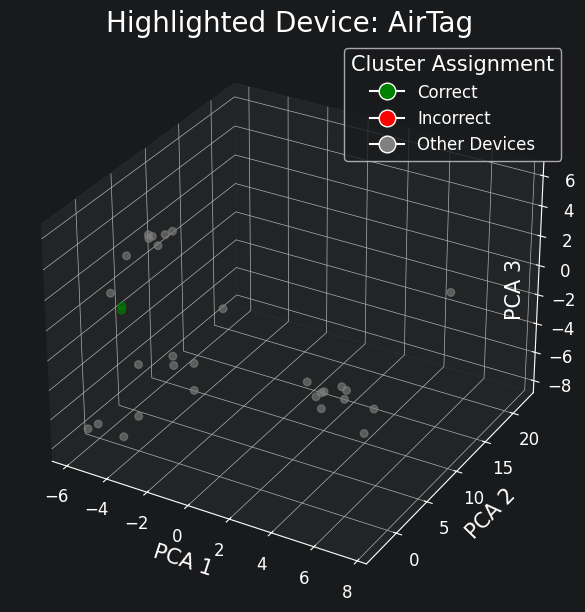

In [64]:
###########################
#      CODE FIELD 13      #
###########################

current_labels = k_means_labels  # k_means_labels, birch_labels, bk_means_labels

# Build DataFrame safely by merging
labels_df = pd.DataFrame({
    'source': agg_df['source'].iloc[:len(current_labels)],  # align with labels
    'cluster_label': current_labels
})

df_to_analyze = labels_df.merge(
    eval_df_binned_balanced[['source', 'labelled_device', 'company_id']],
    on='source',
    how='left'
).drop_duplicates(subset='source')

# Determine the "correct" cluster for each device:
# This is the cluster that contains the majority of that device's points
device_correct_cluster = df_to_analyze.groupby('labelled_device')['cluster_label'] \
                                      .agg(lambda x: x.value_counts().idxmax())

# Add a column indicating whether each point is correctly assigned
df_to_analyze['correct_assignment'] = df_to_analyze.apply(
    lambda row: row['cluster_label'] == device_correct_cluster[row['labelled_device']], axis=1
)

# Count correct and incorrect assignments per device
device_assignment_counts = df_to_analyze.groupby('labelled_device')['correct_assignment'] \
                                        .value_counts().unstack(fill_value=0)
device_assignment_counts.rename(columns={True: 'Correct', False: 'Incorrect'}, inplace=True)
print("Correct/Incorrect assignments per device:\n", device_assignment_counts)

# PCA projection of the scaled data
pca = PCA(n_components=3)
X_3d = pca.fit_transform(X_scaled)

# Map the sources to the device and correctness
mapped_df = df_to_analyze[['source', 'labelled_device', 'correct_assignment']].copy()

# Define the devices you want to visualize
devices_to_show = target_list

for device_to_show in devices_to_show:

    # Assign colors:
    # - Green: sample belongs to this device and is correctly assigned
    # - Red: sample belongs to this device but incorrectly assigned
    # - Gray: sample belongs to other devices
    colors = []
    for idx, row in mapped_df.iterrows():
        if row['labelled_device'] == device_to_show:
            colors.append('green' if row['correct_assignment'] else 'red')
        else:
            colors.append('gray')

    # Plotting
    fig = plt.figure(figsize=(12, 6))
    ax1 = fig.add_subplot(1, 2, 1, projection='3d')
    ax1.scatter(X_3d[:, 0], X_3d[:, 1], X_3d[:, 2], c=colors, alpha=0.6, s=30)
    ax1.set_title(f'Highlighted Device: {device_to_show}', fontsize=20)
    ax1.set_xlabel('PCA 1', fontsize=15)
    ax1.set_ylabel('PCA 2', fontsize=15)
    ax1.tick_params(axis='both', which='major', labelsize=12)  
    ax1.tick_params(axis='z', which='major', labelsize=12)     

    # Legend
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label=f'Correct',
               markerfacecolor='green', markersize=12),
        Line2D([0], [0], marker='o', color='w', label=f'Incorrect',
               markerfacecolor='red', markersize=12),
        Line2D([0], [0], marker='o', color='w', label='Other Devices',
               markerfacecolor='gray', markersize=12),
    ]
    ax1.legend(handles=legend_elements, title='Cluster Assignment', title_fontsize=15, fontsize=12)


    ax1.set_zlabel("") 
    ax1.text2D(
        0.92, 
        0.5, 
        "PCA 3",
        transform=ax1.transAxes,
        rotation=90,
        va="bottom",
        ha="right", 
        fontsize=15
        )

    plt.tight_layout()
    plt.show()
